# 10_baseline_RL_v3 - Reinforcement Learning baseline con filtros de mercado y control de riesgo

Este notebook implementa la tercera iteración del baseline de aprendizaje por refuerzo aplicado a DOGE/USDT.

El objetivo de V3 no es demostrar una estrategia rentable, sino introducir una capa más realista de control operativo sobre el agente tabular construido en V1 y restringido en V2.

La progresión metodológica del bloque RL queda así:

- V1: Entorno mínimo de Q-learning tabular long-only
- V2: Restricciones operativas básicas para reducir acciones inválidas y sobreoperación
- V3: Filtros de mercado, control de riesgo, reward defensivo y evaluación experimental de posiciones long/short simuladas

La principal novedad adicional respecto al plan inicial es la incorporación de shorts simuladas. Esta decisión mantiene coherencia con el bloque de backtesting supervisado y permite evaluar si el agente puede reaccionar de forma más razonable en un tramo de test claramente bajista.

Esta versión evita un stop duro de drawdown de cartera porque bloquearía la evolución de la curva y haría menos informativa la comparación. En su lugar, mantiene defensas blandas que permiten seguir observando el comportamiento del agente:

- Cooldown aplicado también a cierres discrecionales
- Mínimo de velas en posición antes de permitir cierres voluntarios
- Stop-loss y take-profit por operación
- Reward penalizado por drawdown
- Position sizing dinámico que reduce exposición cuando aumenta el drawdown

Como el position sizing dinámico puede actuar como una defensa estructural fuerte, el notebook incluye una sección de ablation para comparar V3 con y sin reducción progresiva de exposición. Esto permite separar si la mejora procede del agente y los filtros o si depende principalmente de limitar el tamaño de las nuevas posiciones cuando la cartera ya va mal.

La ablation ejecutada muestra que las shorts simuladas no aportan una mejora robusta en esta configuración. La variante fixed-size long-only obtiene un resultado prácticamente equivalente a la V3 dinámica long/short, mientras que la variante fixed-size long/short cae de forma clara. Por tanto, las shorts deben interpretarse como una extensión experimental útil para diagnóstico, no como una mejora validada.

La contabilidad short se trata como una simulación simplificada con fines académicos. No modela margen real, liquidaciones, funding ni restricciones propias de derivados. Es una aproximación para estudiar dirección de mercado, no una simulación completa de operativa short real.

In [1]:
# ============================================================
# Imports and global configuration
# Se cargan las librerías principales y se define la configuración general del experimento RL V3.
# V3 mantiene Q-learning tabular para aislar el efecto de los filtros de régimen, el control de riesgo y la ampliación long/short del entorno.
# ============================================================

from pathlib import Path
from collections import defaultdict
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import gymnasium as gym
    from gymnasium import spaces
    GYM_BACKEND = "gymnasium"
except ImportError:
    try:
        import gym
        from gym import spaces
        GYM_BACKEND = "gym"
    except ImportError as exc:
        raise ImportError(
            "No se ha encontrado gymnasium ni gym. Instala una de estas dependencias antes de ejecutar el notebook: "
            "pip install gymnasium"
        ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INITIAL_BALANCE = 1000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
TRAIN_FRACTION = 0.80
MAX_TRAIN_EPISODE_STEPS = 2_500
N_EPISODES = 50

POSITION_SIZE_PCT = 0.25
MIN_POSITION_SIZE_PCT = 0.10
DRAWDOWN_POSITION_SCALING_FLOOR = 0.50
COOLDOWN_STEPS = 12
MIN_HOLDING_STEPS = 12
TRADE_REWARD_PENALTY = 0.00040
INVALID_ACTION_PENALTY = 0.00010
DRAWDOWN_REWARD_PENALTY = 0.00300
STOP_LOSS_PCT = 0.010
TAKE_PROFIT_PCT = 0.020
VOLATILITY_THRESHOLD_QUANTILE = 0.70
TREND_STRENGTH_THRESHOLD_QUANTILE = 0.60
MAX_PORTFOLIO_DRAWDOWN_PCT = None

NOTEBOOK_ID = "10_baseline_RL_v3"

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Gym backend: {GYM_BACKEND}")
print(f"Results directory: {RESULTS_DIR.resolve()}")


Gym backend: gymnasium
Results directory: C:\Users\elwya\Documents\programacion\python\jupyter notebook\M10\TFM\Repository\cryptobot-tfm\results


In [2]:
# ============================================================
# Load engineered DOGEUSDT dataset
# Se carga el dataset enriquecido generado en el pipeline de feature engineering.
# ============================================================

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el dataset enriquecido. Revisa la ruta definida en DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])
    df = df.sort_values("open_time").reset_index(drop=True)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Dataset loaded from: ..\data\processed\DOGEUSDT_5m_binance_2017_2026_features.csv
Shape: (723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [3]:
# ============================================================
# Dataset validation, regime filters and feature selection
# Se validan las columnas necesarias, se construyen filtros simples de régimen y se seleccionan variables observables sin leakage.
# Los filtros se calculan con indicadores ya disponibles en el dataset, por lo que no se introduce información futura.
# ============================================================

required_columns = ["close", "ema_10", "ema_50", "atr_14"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns for RL V3: {missing_required}")

excluded_columns = [
    "open_time",
    "close_time",
    "future_close_1",
    "future_return_1",
    "up_1",
    "future_close_3",
    "future_return_3",
    "up_3",
    "future_close_6",
    "future_return_6",
    "up_6",
    "future_close_12",
    "future_return_12",
    "up_12",
]

rl_df = df.copy()
rl_df["trend_strength"] = (rl_df["ema_10"] / rl_df["ema_50"]) - 1
rl_df["trend_strength_abs"] = rl_df["trend_strength"].abs()
rl_df["atr_close_ratio"] = rl_df["atr_14"] / rl_df["close"]
rl_df["atr_close_ratio_feature"] = rl_df["atr_close_ratio"]

trend_strength_threshold = (
    rl_df["trend_strength_abs"]
    .replace([np.inf, -np.inf], np.nan)
    .quantile(TREND_STRENGTH_THRESHOLD_QUANTILE)
)

volatility_threshold = (
    rl_df["atr_close_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .quantile(VOLATILITY_THRESHOLD_QUANTILE)
)

rl_df["strong_trend_filter"] = rl_df["trend_strength_abs"] >= trend_strength_threshold
rl_df["trend_long_filter"] = (rl_df["ema_10"] > rl_df["ema_50"]) & rl_df["strong_trend_filter"]
rl_df["trend_short_filter"] = (rl_df["ema_10"] < rl_df["ema_50"]) & rl_df["strong_trend_filter"]
rl_df["volatility_allowed"] = rl_df["atr_close_ratio"] <= volatility_threshold

preferred_rl_features = [
    "return_prev_1",
    "log_return_prev_1",
    "ema10_ema50_ratio",
    "ema50_ema200_ratio",
    "sma20_ema50_ratio",
    "volatility_1h",
    "zscore_close_1h",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "bb_width",
    "bb_percent",
    "atr_14",
    "trend_strength",
    "trend_strength_abs",
    "atr_close_ratio_feature",
    "price_position_in_recent_range",
    "dist_to_nearest_support",
    "dist_to_nearest_resistance",
    "near_support",
    "near_resistance",
    "support_strength",
    "resistance_strength",
    "touch_count_near_level",
]

numeric_cols = rl_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in preferred_rl_features if col in numeric_cols and col not in excluded_columns and col != "close"]

if len(feature_cols) == 0:
    raise ValueError("No se encontraron features válidas para el entorno RL V3.")

base_cols = [
    "close",
    "strong_trend_filter",
    "trend_long_filter",
    "trend_short_filter",
    "volatility_allowed",
    "atr_close_ratio",
    "trend_strength_abs",
]

if "open_time" in rl_df.columns:
    base_cols = ["open_time"] + base_cols

rl_df = rl_df[base_cols + feature_cols].copy()
rl_df = rl_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

filter_summary_df = pd.DataFrame([{
    "volatility_threshold_quantile": VOLATILITY_THRESHOLD_QUANTILE,
    "atr_close_ratio_threshold": volatility_threshold,
    "trend_strength_threshold_quantile": TREND_STRENGTH_THRESHOLD_QUANTILE,
    "trend_strength_abs_threshold": trend_strength_threshold,
    "strong_trend_share_%": rl_df["strong_trend_filter"].mean() * 100,
    "trend_long_share_%": rl_df["trend_long_filter"].mean() * 100,
    "trend_short_share_%": rl_df["trend_short_filter"].mean() * 100,
    "volatility_allowed_share_%": rl_df["volatility_allowed"].mean() * 100,
}])

print(f"Number of selected RL features: {len(feature_cols)}")
display(pd.DataFrame({"feature": feature_cols}))
print(f"RL dataset shape after cleaning: {rl_df.shape}")
display(filter_summary_df)


Number of selected RL features: 25


,feature
0,return_prev_1
1,log_return_prev_1
2,ema10_ema50_ratio
3,ema50_ema200_ratio
4,sma20_ema50_ratio
5,volatility_1h
6,zscore_close_1h
7,rsi_14
8,macd
9,macd_signal


RL dataset shape after cleaning: (723080, 33)


,volatility_threshold_quantile,atr_close_ratio_threshold,trend_strength_threshold_quantile,trend_strength_abs_threshold,strong_trend_share_%,trend_long_share_%,trend_short_share_%,volatility_allowed_share_%
0,0.7,0.004214,0.6,0.00371,40.0,19.803756,20.196244,70.0


In [4]:
# ============================================================
# Temporal train-test split and feature scaling
# Se separa el dataset en entrenamiento y test siguiendo orden temporal, evitando mezclar observaciones futuras en el entrenamiento.
# El escalado se ajusta solo con train y después se aplica a test para evitar contaminación temporal.
# ============================================================

split_idx = int(len(rl_df) * TRAIN_FRACTION)
train_df = rl_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = rl_df.iloc[split_idx:].copy().reset_index(drop=True)

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_df[feature_cols])
test_features_scaled = scaler.transform(test_df[feature_cols])

train_scaled_df = train_df.copy()
test_scaled_df = test_df.copy()
train_scaled_df[feature_cols] = train_features_scaled
test_scaled_df[feature_cols] = test_features_scaled

split_summary = {
    "total_rows": len(rl_df),
    "train_rows": len(train_scaled_df),
    "test_rows": len(test_scaled_df),
    "train_start": train_df["open_time"].iloc[0] if "open_time" in train_df.columns else None,
    "train_end": train_df["open_time"].iloc[-1] if "open_time" in train_df.columns else None,
    "test_start": test_df["open_time"].iloc[0] if "open_time" in test_df.columns else None,
    "test_end": test_df["open_time"].iloc[-1] if "open_time" in test_df.columns else None,
}

split_summary_df = pd.DataFrame([split_summary])
display(split_summary_df)

,total_rows,train_rows,test_rows,train_start,train_end,test_start,test_end
0,723080,578464,144616,2019-07-06 11:55:00,2025-01-06 06:50:00,2025-01-06 06:55:00,2026-05-23 10:10:00


## Comentarios - Split temporal y filtros de régimen

El experimento mantiene la partición temporal del bloque RL anterior para que V1, V2 y V3 sean comparables.

La V3 añade filtros calculados con información disponible en cada vela:

- Filtro long cuando `ema_10 > ema_50`
- Filtro short cuando `ema_10 < ema_50`
- Filtro de fuerza mínima de tendencia basado en `abs((ema_10 / ema_50) - 1)`
- Filtro de volatilidad basado en `atr_14 / close`

Estos filtros no garantizan rentabilidad. Funcionan como restricciones defensivas del entorno para evitar que el agente abra posiciones en cualquier régimen de mercado.


In [5]:
# ============================================================
# Trading environment definition with regime filters, risk controls and simulated shorts
# Se define un entorno compatible con Gym para simular decisiones secuenciales con HOLD, OPEN_LONG, CLOSE_LONG, OPEN_SHORT y CLOSE_SHORT.
# La V3 incorpora filtros de tendencia y volatilidad, position sizing menor, stop-loss, take-profit, mínimo de permanencia y control de drawdown sin freno duro de cartera.
# ============================================================

class DogeTradingEnvV3(gym.Env):
    metadata = {"render_modes": []}

    ACTION_LABELS = {
        0: "HOLD",
        1: "OPEN_LONG",
        2: "CLOSE_LONG",
        3: "OPEN_SHORT",
        4: "CLOSE_SHORT",
    }

    def __init__(
        self,
        data,
        feature_columns,
        initial_balance=1000.0,
        fee_rate=0.001,
        slippage_rate=0.0005,
        position_size_pct=0.25,
        min_position_size_pct=0.10,
        drawdown_position_scaling_floor=0.50,
        cooldown_steps=12,
        min_holding_steps=12,
        trade_reward_penalty=0.00040,
        invalid_action_penalty=0.00010,
        drawdown_reward_penalty=0.00300,
        stop_loss_pct=0.010,
        take_profit_pct=0.020,
        max_portfolio_drawdown_pct=None,
        random_start=False,
        max_episode_steps=None,
        seed=42,
    ):
        super().__init__()
        self.data = data.reset_index(drop=True).copy()
        self.feature_columns = feature_columns
        self.initial_balance = float(initial_balance)
        self.fee_rate = float(fee_rate)
        self.slippage_rate = float(slippage_rate)
        self.position_size_pct = float(position_size_pct)
        self.min_position_size_pct = float(min_position_size_pct)
        self.drawdown_position_scaling_floor = float(drawdown_position_scaling_floor)
        self.cooldown_steps = int(cooldown_steps)
        self.min_holding_steps = int(min_holding_steps)
        self.trade_reward_penalty = float(trade_reward_penalty)
        self.invalid_action_penalty = float(invalid_action_penalty)
        self.drawdown_reward_penalty = float(drawdown_reward_penalty)
        self.stop_loss_pct = float(stop_loss_pct)
        self.take_profit_pct = float(take_profit_pct)
        self.max_portfolio_drawdown_pct = None if max_portfolio_drawdown_pct is None else float(max_portfolio_drawdown_pct)
        self.random_start = random_start
        self.max_episode_steps = max_episode_steps
        self.rng = np.random.default_rng(seed)

        if not 0 < self.position_size_pct <= 1:
            raise ValueError("position_size_pct debe estar en el intervalo (0, 1].")

        if self.min_holding_steps < 0:
            raise ValueError("min_holding_steps debe ser mayor o igual que 0.")

        if not 0 < self.min_position_size_pct <= self.position_size_pct:
            raise ValueError("min_position_size_pct debe estar en el intervalo (0, position_size_pct].")

        if self.drawdown_position_scaling_floor <= 0:
            raise ValueError("drawdown_position_scaling_floor debe ser mayor que 0.")

        self.action_space = spaces.Discrete(5)
        obs_size = len(self.feature_columns) + 5
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        self.reset()

    def _get_price(self):
        return float(self.data.loc[self.current_step, "close"])

    def _get_equity(self):
        price = self._get_price()

        if self.position_side == 1:
            return self.cash + self.position_units * price

        if self.position_side == -1:
            unrealized_pnl = self.position_units * (self.entry_price - price)
            return self.cash + self.position_margin + unrealized_pnl

        return self.cash

    def _get_unrealized_pnl_pct(self):
        if self.position_side == 0 or self.entry_price is None:
            return 0.0

        price = self._get_price()

        if self.position_side == 1:
            return price / self.entry_price - 1

        return self.entry_price / price - 1

    def _get_current_drawdown(self):
        current_equity = max(self._get_equity(), 1e-12)
        peak_equity = max(self.peak_equity, current_equity, 1e-12)
        return current_equity / peak_equity - 1

    def _get_effective_position_size_pct(self):
        current_drawdown_abs = min(abs(self._get_current_drawdown()), self.drawdown_position_scaling_floor)
        drawdown_factor = 1 - (current_drawdown_abs / self.drawdown_position_scaling_floor)
        dynamic_size = self.min_position_size_pct + (self.position_size_pct - self.min_position_size_pct) * drawdown_factor
        return float(np.clip(dynamic_size, self.min_position_size_pct, self.position_size_pct))

    def _get_regime_flags(self):
        row = self.data.loc[self.current_step]
        return {
            "trend_long_allowed": bool(row["trend_long_filter"]),
            "trend_short_allowed": bool(row["trend_short_filter"]),
            "volatility_allowed": bool(row["volatility_allowed"]),
        }

    def _get_observation(self):
        features = self.data.loc[self.current_step, self.feature_columns].to_numpy(dtype=np.float32)
        equity = max(self._get_equity(), 1e-12)
        position_side = np.float32(self.position_side)
        cash_ratio = np.float32(self.cash / equity)
        cooldown_ratio = np.float32(self.cooldown_remaining / max(self.cooldown_steps, 1))
        position_age_ratio = np.float32(min(self.position_age / max(self.min_holding_steps, 1), 1.0))
        unrealized_pnl = np.float32(self._get_unrealized_pnl_pct())
        return np.concatenate([features, [position_side, cash_ratio, cooldown_ratio, position_age_ratio, unrealized_pnl]]).astype(np.float32)

    def get_valid_actions(self):
        valid_actions = [0]
        regime = self._get_regime_flags()
        can_open = (
            self.cooldown_remaining == 0
            and self.position_side == 0
            and self.cash > 1e-12
        )
        can_close_discretionary = (
            self.position_side != 0
            and self.cooldown_remaining == 0
            and self.position_age >= self.min_holding_steps
        )

        if can_open and regime["volatility_allowed"] and regime["trend_long_allowed"]:
            valid_actions.append(1)

        if self.position_side == 1 and can_close_discretionary:
            valid_actions.append(2)

        if can_open and regime["volatility_allowed"] and regime["trend_short_allowed"]:
            valid_actions.append(3)

        if self.position_side == -1 and can_close_discretionary:
            valid_actions.append(4)

        return valid_actions

    def _get_position_risk_exit_action(self):
        if self.position_side == 0 or self.entry_price is None:
            return None, None

        price = self._get_price()

        if self.position_side == 1:
            if price <= self.entry_price * (1 - self.stop_loss_pct):
                return 2, "STOP_LOSS"
            if price >= self.entry_price * (1 + self.take_profit_pct):
                return 2, "TAKE_PROFIT"

        if self.position_side == -1:
            if price >= self.entry_price * (1 + self.stop_loss_pct):
                return 4, "STOP_LOSS"
            if price <= self.entry_price * (1 - self.take_profit_pct):
                return 4, "TAKE_PROFIT"

        return None, None

    def _get_risk_exit_action(self):
        return self._get_position_risk_exit_action()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        max_start = max(1, len(self.data) - (self.max_episode_steps or len(self.data)) - 2)
        if self.random_start and max_start > 1:
            self.current_step = int(self.rng.integers(0, max_start))
        else:
            self.current_step = 0

        self.start_step = self.current_step
        self.cash = self.initial_balance
        self.position_side = 0
        self.position_units = 0.0
        self.position_margin = 0.0
        self.entry_price = None
        self.position_age = 0
        self.cooldown_remaining = 0
        self.last_equity = self.initial_balance
        self.peak_equity = self.initial_balance
        self.trade_log = []
        self.equity_curve = []
        self.action_history = []
        self.executed_action_history = []
        self.position_history = []
        self.exposure_history = []
        self.effective_position_size_history = []
        self.drawdown_history = []
        self.exit_reason_history = []
        self.invalid_action_count = 0
        self.forced_exit_count = 0

        obs = self._get_observation()
        info = {"equity": self.last_equity, "valid_actions": self.get_valid_actions()}
        return obs, info

    def _open_long(self, price):
        execution_price = price * (1 + self.slippage_rate)
        equity = max(self._get_equity(), 1e-12)
        cash_to_invest = min(self.cash, equity * self._get_effective_position_size_pct())
        cash_after_fee = cash_to_invest * (1 - self.fee_rate)
        bought_units = cash_after_fee / execution_price

        self.cash -= cash_to_invest
        self.position_units = bought_units
        self.position_side = 1
        self.position_margin = 0.0
        self.entry_price = execution_price
        self.position_age = 0

    def _close_long(self, price):
        execution_price = price * (1 - self.slippage_rate)
        gross_cash = self.position_units * execution_price
        self.cash += gross_cash * (1 - self.fee_rate)
        self.position_side = 0
        self.position_units = 0.0
        self.position_margin = 0.0
        self.entry_price = None
        self.position_age = 0

    def _open_short(self, price):
        execution_price = price * (1 - self.slippage_rate)
        equity = max(self._get_equity(), 1e-12)
        margin = min(self.cash, equity * self._get_effective_position_size_pct())
        notional_after_fee = margin * (1 - self.fee_rate)
        short_units = notional_after_fee / execution_price

        self.cash -= margin
        self.position_units = short_units
        self.position_side = -1
        self.position_margin = margin
        self.entry_price = execution_price
        self.position_age = 0

    def _close_short(self, price):
        execution_price = price * (1 + self.slippage_rate)
        gross_cost = self.position_units * execution_price
        pnl = self.position_units * (self.entry_price - execution_price)
        closing_fee = gross_cost * self.fee_rate

        self.cash += self.position_margin + pnl - closing_fee
        self.position_side = 0
        self.position_units = 0.0
        self.position_margin = 0.0
        self.entry_price = None
        self.position_age = 0

    def step(self, action):
        action = int(action)
        price = self._get_price()
        previous_equity = max(self._get_equity(), 1e-12)
        valid_actions = self.get_valid_actions()
        risk_exit_action, exit_reason = self._get_risk_exit_action()
        forced_exit = risk_exit_action is not None
        invalid_action = False
        executed_trade = "HOLD"

        if forced_exit:
            action_to_execute = risk_exit_action
            self.forced_exit_count += 1
        elif action not in valid_actions:
            self.invalid_action_count += 1
            invalid_action = True
            action_to_execute = 0
            exit_reason = "INVALID_TO_HOLD"
        else:
            action_to_execute = action
            exit_reason = None

        if action_to_execute == 1:
            self._open_long(price)
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "OPEN_LONG"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price, "exit_reason": exit_reason})

        elif action_to_execute == 2 and self.position_side == 1:
            self._close_long(price)
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "CLOSE_LONG"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price, "exit_reason": exit_reason})

        elif action_to_execute == 3:
            self._open_short(price)
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "OPEN_SHORT"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price, "exit_reason": exit_reason})

        elif action_to_execute == 4 and self.position_side == -1:
            self._close_short(price)
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "CLOSE_SHORT"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price, "exit_reason": exit_reason})

        else:
            if self.cooldown_remaining > 0:
                self.cooldown_remaining -= 1

        self.current_step += 1

        reached_end = self.current_step >= len(self.data) - 1
        reached_max_steps = self.max_episode_steps is not None and (self.current_step - self.start_step) >= self.max_episode_steps
        terminated = reached_end
        truncated = bool(reached_max_steps and not reached_end)

        if self.position_side != 0:
            self.position_age += 1

        current_equity = max(self._get_equity(), 1e-12)
        self.peak_equity = max(self.peak_equity, current_equity)
        current_drawdown = current_equity / self.peak_equity - 1

        reward = np.log(current_equity / previous_equity)

        if executed_trade != "HOLD":
            reward -= self.trade_reward_penalty

        if invalid_action:
            reward -= self.invalid_action_penalty

        reward -= self.drawdown_reward_penalty * abs(current_drawdown)

        if self.position_side == 1:
            exposure = (self.position_units * self._get_price()) / current_equity if current_equity > 0 else 0.0
        elif self.position_side == -1:
            exposure = self.position_margin / current_equity if current_equity > 0 else 0.0
        else:
            exposure = 0.0

        effective_position_size_pct = self._get_effective_position_size_pct()

        regime = self._get_regime_flags()

        self.last_equity = current_equity
        self.equity_curve.append(current_equity)
        self.action_history.append(action)
        self.executed_action_history.append(action_to_execute)
        self.position_history.append(self.position_side)
        self.exposure_history.append(exposure)
        self.effective_position_size_history.append(effective_position_size_pct)
        self.drawdown_history.append(current_drawdown)
        self.exit_reason_history.append(exit_reason)

        obs = self._get_observation()
        info = {
            "equity": current_equity,
            "price": self._get_price(),
            "executed_trade": executed_trade,
            "requested_action": action,
            "executed_action": action_to_execute,
            "invalid_action": invalid_action,
            "forced_exit": forced_exit,
            "exit_reason": exit_reason,
            "position_side": self.position_side,
            "cash": self.cash,
            "position_units": self.position_units,
            "position_margin": self.position_margin,
            "entry_price": self.entry_price,
            "position_age": self.position_age,
            "exposure": exposure,
            "effective_position_size_pct": effective_position_size_pct,
            "drawdown": current_drawdown,
            "cooldown_remaining": self.cooldown_remaining,
            "trend_long_allowed": regime["trend_long_allowed"],
            "trend_short_allowed": regime["trend_short_allowed"],
            "volatility_allowed": regime["volatility_allowed"],
            "valid_actions": self.get_valid_actions(),
        }

        return obs, float(reward), terminated, truncated, info


In [6]:
# ============================================================
# Environment smoke test without valid-action masking
# Se ejecuta una prueba corta con acciones aleatorias sin consultar la máscara de acciones válidas.
# Esta prueba valida que el entorno responde ante acciones inválidas, filtros de régimen y cierres automáticos por operación sin romper la ejecución.
# ============================================================

env_check = DogeTradingEnvV3(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    min_position_size_pct=MIN_POSITION_SIZE_PCT,
    drawdown_position_scaling_floor=DRAWDOWN_POSITION_SCALING_FLOOR,
    cooldown_steps=COOLDOWN_STEPS,
    min_holding_steps=MIN_HOLDING_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    drawdown_reward_penalty=DRAWDOWN_REWARD_PENALTY,
    stop_loss_pct=STOP_LOSS_PCT,
    take_profit_pct=TAKE_PROFIT_PCT,
    max_portfolio_drawdown_pct=MAX_PORTFOLIO_DRAWDOWN_PCT,
    random_start=True,
    max_episode_steps=100,
    seed=RANDOM_STATE,
)

obs, info = env_check.reset(seed=RANDOM_STATE)
smoke_records = []

done = False
while not done:
    action = env_check.action_space.sample()
    obs, reward, terminated, truncated, info = env_check.step(action)
    smoke_records.append({
        "requested_action": action,
        "executed_action": info["executed_action"],
        "executed_trade": info["executed_trade"],
        "invalid_action": info["invalid_action"],
        "forced_exit": info["forced_exit"],
        "exit_reason": info["exit_reason"],
        "equity": info["equity"],
        "position_side": info["position_side"],
        "exposure": info["exposure"],
        "effective_position_size_pct": info["effective_position_size_pct"],
        "reward": reward,
    })
    done = terminated or truncated

smoke_test_df = pd.DataFrame(smoke_records)
smoke_summary_df = pd.DataFrame([{
    "steps": len(smoke_test_df),
    "final_equity": smoke_test_df["equity"].iloc[-1],
    "executed_trade_events": int((smoke_test_df["executed_trade"] != "HOLD").sum()),
    "invalid_actions": int(smoke_test_df["invalid_action"].sum()),
    "forced_risk_exits": int(smoke_test_df["forced_exit"].sum()),
    "mean_exposure": smoke_test_df["exposure"].mean(),
    "mean_effective_position_size_pct": smoke_test_df["effective_position_size_pct"].mean(),
}])

display(smoke_test_df.head())
display(smoke_summary_df)

,requested_action,executed_action,executed_trade,invalid_action,forced_exit,exit_reason,equity,position_side,exposure,effective_position_size_pct,reward
0,3,0,HOLD,True,False,INVALID_TO_HOLD,1000.0,0,0.0,0.25,-0.0001
1,1,0,HOLD,True,False,INVALID_TO_HOLD,1000.0,0,0.0,0.25,-0.0001
2,0,0,HOLD,False,False,None,1000.0,0,0.0,0.25,0.0000
3,2,0,HOLD,True,False,INVALID_TO_HOLD,1000.0,0,0.0,0.25,-0.0001
4,2,0,HOLD,True,False,INVALID_TO_HOLD,1000.0,0,0.0,0.25,-0.0001


,steps,final_equity,executed_trade_events,invalid_actions,forced_risk_exits,mean_exposure,mean_effective_position_size_pct
0,100,1000.0,0,75,0,0.0,0.25


## Comentarios - Smoke test del entorno

El smoke test no evalúa la política entrenada. Usa acciones aleatorias sin máscara para comprobar que el entorno V3 es robusto ante decisiones absurdas.

Por eso pueden aparecer acciones inválidas aunque el entrenamiento posterior sí use `get_valid_actions()`. En V3 esas acciones no se ejecutan: se registran, se convierten en HOLD y reciben una penalización diagnóstica.

La novedad relevante es que el entorno puede cerrar posiciones automáticamente por stop-loss o take-profit. El drawdown de cartera no detiene el episodio: penaliza el reward y reduce progresivamente el tamaño efectivo de nuevas posiciones.


In [7]:
# ============================================================
# Q-learning helper functions with valid-action masking
# Se implementa una política Q-learning tabular sobre una discretización sencilla del estado observado por el entorno.
# La selección de acciones usa una máscara de acciones válidas para respetar filtros de régimen, estado de posición, cooldown y mínimo de permanencia.
# ============================================================

selected_state_features = [
    col for col in [
        "return_prev_1",
        "zscore_close_1h",
        "rsi_14",
        "macd_hist",
        "bb_percent",
        "price_position_in_recent_range",
        "volatility_1h",
        "trend_strength",
        "trend_strength_abs",
        "atr_close_ratio_feature",
    ]
    if col in feature_cols
]

state_feature_indices = [feature_cols.index(col) for col in selected_state_features]
position_side_index = len(feature_cols)
cash_ratio_index = len(feature_cols) + 1
cooldown_index = len(feature_cols) + 2
position_age_index = len(feature_cols) + 3
unrealized_pnl_index = len(feature_cols) + 4

state_bins = np.array([-1.5, -0.75, 0.0, 0.75, 1.5])
pnl_bins = np.array([-0.03, -0.01, 0.0, 0.01, 0.03])


def discretize_observation(obs):
    feature_state = tuple(np.digitize(obs[idx], state_bins) for idx in state_feature_indices)
    position_state = int(np.sign(obs[position_side_index]))
    cash_state = int(obs[cash_ratio_index] > 0.5)
    cooldown_state = int(obs[cooldown_index] > 0.0)
    position_age_state = int(obs[position_age_index] >= 1.0)
    pnl_state = int(np.digitize(obs[unrealized_pnl_index], pnl_bins))
    return feature_state + (position_state, cash_state, cooldown_state, position_age_state, pnl_state)


def choose_action(q_table, state, epsilon, valid_actions, n_actions=5):
    valid_actions = list(valid_actions)

    if np.random.random() < epsilon:
        return int(np.random.choice(valid_actions))

    q_values = q_table[state].copy()
    invalid_actions = [action for action in range(n_actions) if action not in valid_actions]
    q_values[invalid_actions] = -np.inf
    return int(np.argmax(q_values))


print(f"State features used by Q-learning: {selected_state_features}")


State features used by Q-learning: ['return_prev_1', 'zscore_close_1h', 'rsi_14', 'macd_hist', 'bb_percent', 'price_position_in_recent_range', 'volatility_1h', 'trend_strength', 'trend_strength_abs', 'atr_close_ratio_feature']


In [8]:
# ============================================================
# Train tabular Q-learning agent
# Se entrena un agente Q-learning durante un número reducido de episodios con inicios aleatorios dentro del tramo de entrenamiento.
# La V3 aprende usando acciones válidas, filtros de régimen, shorts simuladas, stop-loss, take-profit, reward penalizado por drawdown y position sizing dinámico.
# ============================================================

train_env = DogeTradingEnvV3(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    min_position_size_pct=MIN_POSITION_SIZE_PCT,
    drawdown_position_scaling_floor=DRAWDOWN_POSITION_SCALING_FLOOR,
    cooldown_steps=COOLDOWN_STEPS,
    min_holding_steps=MIN_HOLDING_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    drawdown_reward_penalty=DRAWDOWN_REWARD_PENALTY,
    stop_loss_pct=STOP_LOSS_PCT,
    take_profit_pct=TAKE_PROFIT_PCT,
    max_portfolio_drawdown_pct=MAX_PORTFOLIO_DRAWDOWN_PCT,
    random_start=True,
    max_episode_steps=MAX_TRAIN_EPISODE_STEPS,
    seed=RANDOM_STATE,
)

q_table = defaultdict(lambda: np.zeros(train_env.action_space.n, dtype=np.float64))

alpha = 0.08
gamma = 0.95
epsilon_start = 1.00
epsilon_end = 0.05
epsilon_decay = 0.94

episode_metrics = []
epsilon = epsilon_start

for episode in range(1, N_EPISODES + 1):
    obs, info = train_env.reset(seed=RANDOM_STATE + episode)
    state = discretize_observation(obs)
    total_reward = 0.0
    done = False
    steps = 0

    while not done:
        valid_actions = train_env.get_valid_actions()
        action = choose_action(q_table, state, epsilon, valid_actions, train_env.action_space.n)
        next_obs, reward, terminated, truncated, info = train_env.step(action)
        next_state = discretize_observation(next_obs)

        next_valid_actions = train_env.get_valid_actions()
        next_q_values = q_table[next_state][next_valid_actions]
        best_next_q = np.max(next_q_values)

        q_table[state][action] += alpha * (reward + gamma * best_next_q - q_table[state][action])

        state = next_state
        total_reward += reward
        steps += 1
        done = terminated or truncated

    episode_trade_log_df = pd.DataFrame(train_env.trade_log)

    episode_metrics.append({
        "episode": episode,
        "steps": steps,
        "total_reward": total_reward,
        "final_equity": info["equity"],
        "epsilon": epsilon,
        "num_trade_events": len(train_env.trade_log),
        "long_entries": int((episode_trade_log_df["action"] == "OPEN_LONG").sum()) if not episode_trade_log_df.empty else 0,
        "short_entries": int((episode_trade_log_df["action"] == "OPEN_SHORT").sum()) if not episode_trade_log_df.empty else 0,
        "forced_risk_exits": train_env.forced_exit_count,
        "invalid_actions": train_env.invalid_action_count,
        "mean_exposure": np.mean(train_env.exposure_history) if train_env.exposure_history else 0.0,
        "mean_effective_position_size_pct": np.mean(train_env.effective_position_size_history) if train_env.effective_position_size_history else 0.0,
        "max_drawdown": np.min(train_env.drawdown_history) if train_env.drawdown_history else 0.0,
    })

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

training_metrics_df = pd.DataFrame(episode_metrics)
display(training_metrics_df.tail(10))
print(f"Number of learned states: {len(q_table)}")

,episode,steps,total_reward,final_equity,epsilon,num_trade_events,long_entries,short_entries,forced_risk_exits,invalid_actions,mean_exposure,mean_effective_position_size_pct,max_drawdown
40,41,2500,-0.124402,973.723145,0.084162,42,8,13,3,0,0.033129,0.246761,-0.026623
41,42,2500,-0.090308,992.327381,0.079112,58,14,15,7,0,0.039354,0.247624,-0.022790
42,43,2500,-0.046145,998.236080,0.074365,42,7,14,5,0,0.030752,0.248897,-0.008325
43,44,2500,-0.164480,971.612327,0.069903,72,17,19,8,0,0.053171,0.245725,-0.028388
44,45,2500,-0.137327,989.373123,0.065709,66,16,17,8,0,0.045055,0.245990,-0.026270
45,46,2500,-0.088298,988.401210,0.061767,52,15,11,11,0,0.038271,0.247767,-0.016226
46,47,2500,-0.057300,996.287863,0.058061,18,3,6,3,0,0.011817,0.248145,-0.014711
47,48,2500,-0.086901,997.050562,0.054577,66,17,16,7,0,0.046906,0.247698,-0.020771
48,49,2500,-0.134507,977.128040,0.051302,64,16,16,8,0,0.045663,0.246569,-0.026695
49,50,2500,-0.139575,990.326843,0.050000,70,18,17,9,0,0.048403,0.245926,-0.021537


Number of learned states: 22382


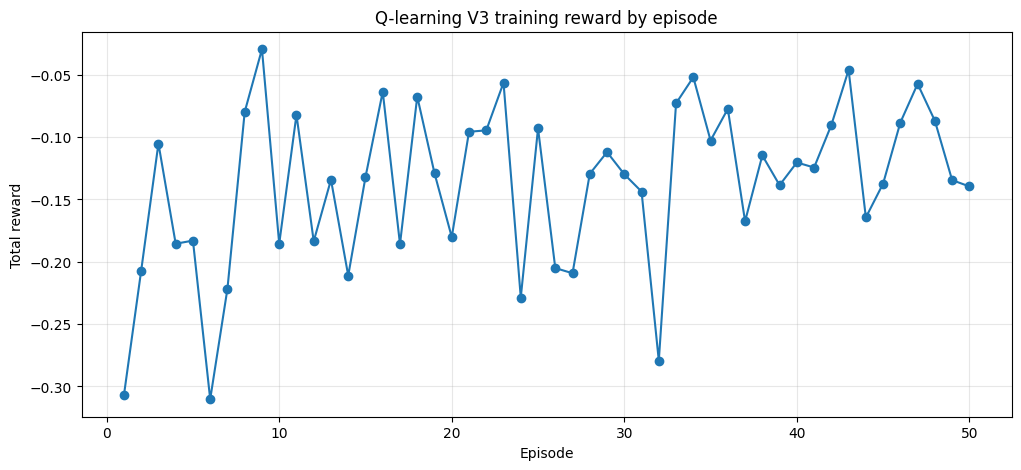

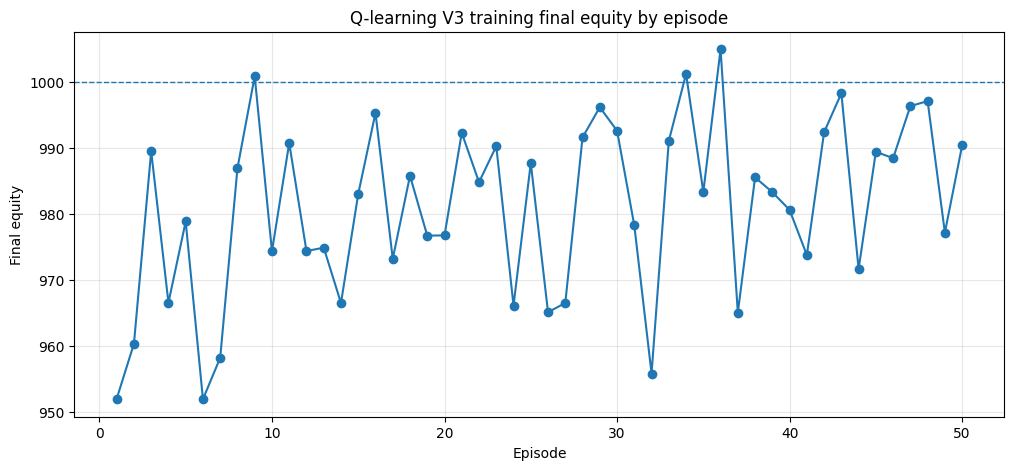

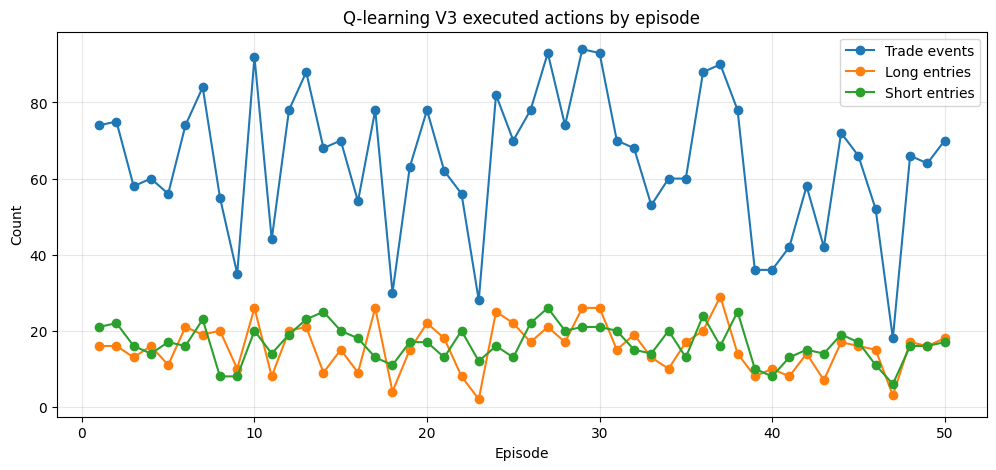

,episodes,mean_total_reward,best_total_reward,worst_total_reward,mean_final_equity,best_final_equity,worst_final_equity,mean_trade_events,mean_long_entries,mean_short_entries,mean_forced_risk_exits,mean_invalid_actions,mean_exposure,mean_max_drawdown
0,50,-0.137521,-0.0295,-0.310278,981.03559,1004.904358,951.891285,64.66,15.7,16.7,7.22,0.0,0.043238,-0.025626


In [9]:
# ============================================================
# Training diagnostics
# Se visualiza la evolución del reward, equity final, número de operaciones, entradas long/short y drawdown durante el entrenamiento.
# Las gráficas se complementan con una tabla resumen para facilitar la interpretación posterior.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["total_reward"], marker="o")
ax.set_title("Q-learning V3 training reward by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["final_equity"], marker="o")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("Q-learning V3 training final equity by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Final equity")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["num_trade_events"], marker="o", label="Trade events")
ax.plot(training_metrics_df["episode"], training_metrics_df["long_entries"], marker="o", label="Long entries")
ax.plot(training_metrics_df["episode"], training_metrics_df["short_entries"], marker="o", label="Short entries")
ax.set_title("Q-learning V3 executed actions by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

training_summary = {
    "episodes": len(training_metrics_df),
    "mean_total_reward": training_metrics_df["total_reward"].mean(),
    "best_total_reward": training_metrics_df["total_reward"].max(),
    "worst_total_reward": training_metrics_df["total_reward"].min(),
    "mean_final_equity": training_metrics_df["final_equity"].mean(),
    "best_final_equity": training_metrics_df["final_equity"].max(),
    "worst_final_equity": training_metrics_df["final_equity"].min(),
    "mean_trade_events": training_metrics_df["num_trade_events"].mean(),
    "mean_long_entries": training_metrics_df["long_entries"].mean(),
    "mean_short_entries": training_metrics_df["short_entries"].mean(),
    "mean_forced_risk_exits": training_metrics_df["forced_risk_exits"].mean(),
    "mean_invalid_actions": training_metrics_df["invalid_actions"].mean(),
    "mean_exposure": training_metrics_df["mean_exposure"].mean(),
    "mean_max_drawdown": training_metrics_df["max_drawdown"].mean(),
}

training_summary_df = pd.DataFrame([training_summary])
display(training_summary_df)

## Comentarios - Entrenamiento del agente Q-learning V3

El entrenamiento queda mucho más controlado que en la primera V3 suicida. En los 50 episodios, el equity final medio es 981.04 USDT, con mejor episodio en 1004.90 USDT y peor episodio en 951.89 USDT. Esto no implica rentabilidad real, pero sí indica que el entrenamiento ya no está dominado por una explosión de sobreoperación.

La media de eventos de trading por episodio es 64.66 sobre 2.500 pasos, con 15.70 entradas long y 16.70 entradas short de media. Además, no aparecen acciones inválidas, lo que confirma que la máscara de acciones válidas está funcionando durante el aprendizaje.

El mean exposure del entrenamiento es 0.0432 y el mean max drawdown es -2.56 %. Es una señal de que el agente opera poco y con exposición contenida dentro de los episodios de entrenamiento. Aun así, esta lectura debe separarse de la evaluación temporal: los episodios de train usan inicios aleatorios, longitud limitada y una política todavía exploratoria, mientras que el test recorre un tramo temporal completo no visto.

In [10]:
# ============================================================
# Evaluate trained RL policy on temporal test set
# Se evalúa la política aprendida en el tramo de test sin exploración, usando siempre la acción válida con mayor valor Q estimado.
# La evaluación reproduce un backtest simplificado con costes, filtros de régimen, shorts simuladas, cierres automáticos por operación y control blando de drawdown.
# ============================================================

test_env = DogeTradingEnvV3(
    test_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    min_position_size_pct=MIN_POSITION_SIZE_PCT,
    drawdown_position_scaling_floor=DRAWDOWN_POSITION_SCALING_FLOOR,
    cooldown_steps=COOLDOWN_STEPS,
    min_holding_steps=MIN_HOLDING_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    drawdown_reward_penalty=DRAWDOWN_REWARD_PENALTY,
    stop_loss_pct=STOP_LOSS_PCT,
    take_profit_pct=TAKE_PROFIT_PCT,
    max_portfolio_drawdown_pct=MAX_PORTFOLIO_DRAWDOWN_PCT,
    random_start=False,
    max_episode_steps=None,
    seed=RANDOM_STATE,
)

obs, info = test_env.reset(seed=RANDOM_STATE)
state = discretize_observation(obs)
eval_records = []
done = False

while not done:
    valid_actions = test_env.get_valid_actions()
    action = choose_action(q_table, state, epsilon=0.0, valid_actions=valid_actions, n_actions=test_env.action_space.n)
    next_obs, reward, terminated, truncated, info = test_env.step(action)
    next_state = discretize_observation(next_obs)

    record = {
        "step": test_env.current_step,
        "action": action,
        "action_label": DogeTradingEnvV3.ACTION_LABELS.get(action, "UNKNOWN"),
        "executed_action": info["executed_action"],
        "executed_trade": info["executed_trade"],
        "invalid_action": info["invalid_action"],
        "forced_exit": info["forced_exit"],
        "exit_reason": info["exit_reason"],
        "price": info["price"],
        "equity": info["equity"],
        "reward": reward,
        "position_side": info["position_side"],
        "cash": info["cash"],
        "position_units": info["position_units"],
        "position_margin": info["position_margin"],
        "entry_price": info["entry_price"],
        "position_age": info["position_age"],
        "exposure": info["exposure"],
        "effective_position_size_pct": info["effective_position_size_pct"],
        "drawdown": info["drawdown"],
        "cooldown_remaining": info["cooldown_remaining"],
        "trend_long_allowed": info["trend_long_allowed"],
        "trend_short_allowed": info["trend_short_allowed"],
        "volatility_allowed": info["volatility_allowed"],
    }

    if "open_time" in test_scaled_df.columns:
        record["open_time"] = test_scaled_df.loc[min(test_env.current_step, len(test_scaled_df) - 1), "open_time"]

    eval_records.append(record)
    state = next_state
    done = terminated or truncated

rl_eval_df = pd.DataFrame(eval_records)

if "open_time" in rl_eval_df.columns:
    rl_eval_df["open_time"] = pd.to_datetime(rl_eval_df["open_time"])

display(rl_eval_df.head())
display(rl_eval_df.tail())
print(f"Evaluation steps: {len(rl_eval_df)}")
print(f"Executed trade events in test: {len(test_env.trade_log)}")
print(f"Invalid actions in test: {test_env.invalid_action_count}")
print(f"Forced risk exits in test: {test_env.forced_exit_count}")

,step,action,action_label,executed_action,executed_trade,invalid_action,forced_exit,exit_reason,price,equity,...,entry_price,position_age,exposure,effective_position_size_pct,drawdown,cooldown_remaining,trend_long_allowed,trend_short_allowed,volatility_allowed,open_time
0,1,0,HOLD,0,HOLD,False,False,None,0.38310,1000.0,...,NaN,0,0.0,0.25,0.0,0,False,False,True,2025-01-06 07:00:00
1,2,0,HOLD,0,HOLD,False,False,None,0.38295,1000.0,...,NaN,0,0.0,0.25,0.0,0,False,False,True,2025-01-06 07:05:00
2,3,0,HOLD,0,HOLD,False,False,None,0.38286,1000.0,...,NaN,0,0.0,0.25,0.0,0,False,False,True,2025-01-06 07:10:00
3,4,0,HOLD,0,HOLD,False,False,None,0.38148,1000.0,...,NaN,0,0.0,0.25,0.0,0,False,True,True,2025-01-06 07:15:00
4,5,0,HOLD,0,HOLD,False,False,None,0.38122,1000.0,...,NaN,0,0.0,0.25,0.0,0,False,True,True,2025-01-06 07:20:00


,step,action,action_label,executed_action,executed_trade,invalid_action,forced_exit,exit_reason,price,equity,...,entry_price,position_age,exposure,effective_position_size_pct,drawdown,cooldown_remaining,trend_long_allowed,trend_short_allowed,volatility_allowed,open_time
144610,144611,0,HOLD,0,HOLD,False,False,None,0.09946,466.403375,...,0.09962,9,0.099984,0.1,-0.536183,4,False,True,True,2026-05-23 09:50:00
144611,144612,0,HOLD,0,HOLD,False,False,None,0.09940,466.431433,...,0.09962,10,0.099978,0.1,-0.536156,3,False,True,True,2026-05-23 09:55:00
144612,144613,0,HOLD,0,HOLD,False,False,None,0.09942,466.422080,...,0.09962,11,0.099980,0.1,-0.536165,2,False,True,True,2026-05-23 10:00:00
144613,144614,0,HOLD,0,HOLD,False,False,None,0.09946,466.403375,...,0.09962,12,0.099984,0.1,-0.536183,1,False,True,True,2026-05-23 10:05:00
144614,144615,0,HOLD,0,HOLD,False,False,None,0.09955,466.361287,...,0.09962,13,0.099993,0.1,-0.536225,0,False,True,True,2026-05-23 10:10:00


Evaluation steps: 144615
Executed trade events in test: 4237
Invalid actions in test: 0
Forced risk exits in test: 503


In [11]:
# ============================================================
# Buy and Hold benchmark
# Se calcula una estrategia Buy & Hold sobre el mismo tramo de test para comparar el agente RL contra un benchmark pasivo.
# ============================================================

test_prices = test_scaled_df["close"].astype(float).reset_index(drop=True)

buy_hold_units = (INITIAL_BALANCE * (1 - FEE_RATE)) / (test_prices.iloc[0] * (1 + SLIPPAGE_RATE))
buy_hold_equity = buy_hold_units * test_prices

buy_hold_df = pd.DataFrame({
    "price": test_prices,
    "equity": buy_hold_equity,
})

if "open_time" in test_scaled_df.columns:
    buy_hold_df["open_time"] = test_scaled_df["open_time"].reset_index(drop=True)

display(buy_hold_df.head())
display(buy_hold_df.tail())

,price,equity,open_time
0,0.38417,998.500750,2025-01-06 06:55:00
1,0.38310,995.719700,2025-01-06 07:00:00
2,0.38295,995.329833,2025-01-06 07:05:00
3,0.38286,995.095913,2025-01-06 07:10:00
4,0.38148,991.509139,2025-01-06 07:15:00


,price,equity,open_time
144611,0.09946,258.507652,2026-05-23 09:50:00
144612,0.09940,258.351705,2026-05-23 09:55:00
144613,0.09942,258.403687,2026-05-23 10:00:00
144614,0.09946,258.507652,2026-05-23 10:05:00
144615,0.09955,258.741572,2026-05-23 10:10:00


In [12]:
# ============================================================
# Financial and operational metrics helper functions
# Se definen funciones auxiliares para calcular drawdown, Sharpe ratio aproximado y métricas comparables de resultados.
# La V3 añade métricas de entradas long/short, cierres por riesgo, exposición, acciones inválidas y control blando de drawdown.
# ============================================================

def compute_drawdown(equity_series):
    equity_series = pd.Series(equity_series).astype(float)
    running_max = equity_series.cummax()
    drawdown = equity_series / running_max - 1
    return drawdown


def compute_sharpe_from_equity(equity_series, periods_per_year=105_120):
    equity_series = pd.Series(equity_series).astype(float)
    returns = equity_series.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if returns.std() == 0 or len(returns) == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def summarize_strategy(
    equity_series,
    strategy_name,
    action_series=None,
    executed_trade_series=None,
    exposure_series=None,
    invalid_action_series=None,
    forced_exit_series=None,
    exit_reason_series=None,
):
    equity_series = pd.Series(equity_series).astype(float).reset_index(drop=True)
    drawdown = compute_drawdown(equity_series)

    if action_series is not None:
        action_series = pd.Series(action_series).reset_index(drop=True)

    if executed_trade_series is not None:
        executed_trade_series = pd.Series(executed_trade_series).reset_index(drop=True)
        number_of_trade_events = int((executed_trade_series != "HOLD").sum())
        long_entries = int((executed_trade_series == "OPEN_LONG").sum())
        short_entries = int((executed_trade_series == "OPEN_SHORT").sum())
        long_exits = int((executed_trade_series == "CLOSE_LONG").sum())
        short_exits = int((executed_trade_series == "CLOSE_SHORT").sum())
    else:
        number_of_trade_events = np.nan
        long_entries = np.nan
        short_entries = np.nan
        long_exits = np.nan
        short_exits = np.nan

    if exposure_series is not None:
        exposure_series = pd.Series(exposure_series).astype(float).reset_index(drop=True)
        mean_exposure = exposure_series.mean()
        max_exposure = exposure_series.max()
    else:
        mean_exposure = np.nan
        max_exposure = np.nan

    if invalid_action_series is not None:
        invalid_actions = int(pd.Series(invalid_action_series).sum())
    else:
        invalid_actions = np.nan

    if forced_exit_series is not None:
        forced_exits = int(pd.Series(forced_exit_series).sum())
    else:
        forced_exits = np.nan

    if exit_reason_series is not None:
        exit_reason_series = pd.Series(exit_reason_series).fillna("NONE")
        stop_loss_exits = int((exit_reason_series == "STOP_LOSS").sum())
        take_profit_exits = int((exit_reason_series == "TAKE_PROFIT").sum())
    else:
        stop_loss_exits = np.nan
        take_profit_exits = np.nan

    return {
        "strategy": strategy_name,
        "initial_balance": equity_series.iloc[0],
        "final_balance": equity_series.iloc[-1],
        "return_pct": (equity_series.iloc[-1] / equity_series.iloc[0] - 1) * 100,
        "max_drawdown_pct": drawdown.min() * 100,
        "sharpe_ratio_approx": compute_sharpe_from_equity(equity_series),
        "num_periods": len(equity_series),
        "number_of_trade_events": number_of_trade_events,
        "turnover": number_of_trade_events / len(equity_series) if len(equity_series) > 0 and not pd.isna(number_of_trade_events) else np.nan,
        "mean_exposure": mean_exposure,
        "max_exposure": max_exposure,
        "invalid_actions": invalid_actions,
        "forced_risk_exits": forced_exits,
        "stop_loss_exits": stop_loss_exits,
        "take_profit_exits": take_profit_exits,
        "long_entries": long_entries,
        "short_entries": short_entries,
        "long_exits": long_exits,
        "short_exits": short_exits,
    }


In [13]:
# ============================================================
# Load V1 and V2 reference results
# Se cargan directamente los resultados guardados por los notebooks 08 y 09 para reutilizar curvas y métricas previamente obtenidas.
# La comparación no recalcula V1 ni V2: normaliza los CSV persistidos en results y los alinea con el tramo de test actual.
# ============================================================

v1_summary_path = RESULTS_DIR / "08_baseline_RL_summary.csv"
v1_equity_path = RESULTS_DIR / "08_baseline_RL_equity_curve.csv"
v2_summary_path = RESULTS_DIR / "09_baseline_RL_v2_summary.csv"
v2_equity_path = RESULTS_DIR / "09_baseline_RL_v2_equity_curve.csv"

required_reference_paths = [
    v1_summary_path,
    v1_equity_path,
    v2_summary_path,
    v2_equity_path,
]

missing_reference_paths = [path for path in required_reference_paths if not path.exists()]

if missing_reference_paths:
    missing_text = "\n".join(str(path) for path in missing_reference_paths)
    raise FileNotFoundError(
        "Missing previous RL results. Execute notebooks 08 and 09 first, or check ../results/:\n"
        f"{missing_text}"
    )

v1_summary_df = pd.read_csv(v1_summary_path)
v2_summary_df = pd.read_csv(v2_summary_path)
v1_equity_raw_df = pd.read_csv(v1_equity_path)
v2_equity_raw_df = pd.read_csv(v2_equity_path)


def normalize_rl_reference_curve(reference_df, version, expected_len=None):
    reference_df = reference_df.copy().reset_index(drop=True)

    equity_candidates = [
        f"rl_{version}_equity",
        f"{version}_equity",
        "rl_equity",
        "equity",
        "strategy_equity",
        "portfolio_value",
        "balance",
        "total_equity",
    ]

    drawdown_candidates = [
        f"rl_{version}_drawdown",
        f"{version}_drawdown",
        "rl_drawdown",
        "drawdown",
        "strategy_drawdown",
    ]

    buy_hold_candidates = [
        "buy_hold_equity",
        "bh_equity",
        "benchmark_equity",
    ]

    equity_col = next((col for col in equity_candidates if col in reference_df.columns), None)
    drawdown_col = next((col for col in drawdown_candidates if col in reference_df.columns), None)
    buy_hold_col = next((col for col in buy_hold_candidates if col in reference_df.columns), None)

    if equity_col is None:
        raise KeyError(
            f"Could not identify the {version.upper()} equity column in the persisted RL reference. "
            f"Available columns: {list(reference_df.columns)}"
        )

    normalized = pd.DataFrame({
        f"rl_{version}_equity": reference_df[equity_col].astype(float),
    })

    if drawdown_col is not None:
        normalized[f"rl_{version}_drawdown"] = reference_df[drawdown_col].astype(float)
    else:
        normalized[f"rl_{version}_drawdown"] = compute_drawdown(normalized[f"rl_{version}_equity"])

    if buy_hold_col is not None:
        normalized[f"{version}_buy_hold_equity"] = reference_df[buy_hold_col].astype(float)

    if "open_time" in reference_df.columns:
        normalized["open_time"] = pd.to_datetime(reference_df["open_time"])

    if expected_len is not None and len(normalized) != expected_len:
        min_len = min(len(normalized), expected_len)
        print(
            f"Warning: {version.upper()} reference length ({len(normalized)}) does not match current V3 test length ({expected_len}). "
            f"Using the last {min_len} aligned rows."
        )
        normalized = normalized.tail(min_len).reset_index(drop=True)

    return normalized


v1_reference_df = normalize_rl_reference_curve(v1_equity_raw_df, version="v1", expected_len=len(rl_eval_df))
v2_reference_df = normalize_rl_reference_curve(v2_equity_raw_df, version="v2", expected_len=len(rl_eval_df))

print("Loaded RL V1 summary:")
display(v1_summary_df)

print("Loaded RL V2 summary:")
display(v2_summary_df)

print("Normalized RL V1 reference preview:")
display(v1_reference_df.head())

print("Normalized RL V2 reference preview:")
display(v2_reference_df.head())

Loaded RL V1 summary:


,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,num_periods,buy_signals,sell_signals,hold_signals,fees_applied,slippage_applied,position_sizing,main_limitation
0,08_baseline_RL,RL baseline,1000.0,6.646529,-99.335347,-99.398312,-7.406826,144615,15046.0,33602.0,95967.0,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...
1,08_baseline_RL,Buy & Hold,1000.0,258.120019,-74.187998,-81.410760,-0.464415,144615,NaN,NaN,NaN,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...


Loaded RL V2 summary:


,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,num_periods,number_of_trades,turnover,...,buy_signals,sell_signals,hold_signals,fees_applied,slippage_applied,position_sizing,cooldown_steps,trade_reward_penalty,invalid_action_penalty,main_limitation
0,09_baseline_RL_v2,RL V2 baseline,1000.0,136.345883,-86.365412,-86.39388,-6.973000,144615,3108.0,0.021492,...,1554.0,1554.0,141507.0,0.001,0.0005,50% of available cash on BUY,3,0.00005,0.0001,Tabular Q-learning with simple discretized sta...
1,09_baseline_RL_v2,Buy & Hold,1000.0,258.353589,-74.164641,-81.41076,-0.461721,144615,NaN,NaN,...,NaN,NaN,NaN,0.001,0.0005,50% of available cash on BUY,3,0.00005,0.0001,Tabular Q-learning with simple discretized sta...


Normalized RL V1 reference preview:


,rl_v1_equity,rl_v1_drawdown,v1_buy_hold_equity,open_time
0,1000.0,0.0,997.003498,2025-01-06 07:00:00
1,1000.0,0.0,994.226618,2025-01-06 07:05:00
2,1000.0,0.0,993.837336,2025-01-06 07:10:00
3,1000.0,0.0,993.603767,2025-01-06 07:15:00
4,1000.0,0.0,990.022371,2025-01-06 07:20:00


Normalized RL V2 reference preview:


,rl_v2_equity,rl_v2_drawdown,v2_buy_hold_equity,open_time
0,1000.0,0.0,994.226618,2025-01-06 07:00:00
1,1000.0,0.0,993.837336,2025-01-06 07:05:00
2,1000.0,0.0,993.603767,2025-01-06 07:10:00
3,1000.0,0.0,990.022371,2025-01-06 07:15:00
4,1000.0,0.0,989.347615,2025-01-06 07:20:00


## Comentarios - Referencias persistidas de V1 y V2

V3 reutiliza los resultados guardados por los notebooks anteriores en `../results/`.

Esto evita reconstruir V1 y V2 dentro del notebook actual y mantiene una comparación progresiva más limpia:

- V1 se usa como baseline RL mínimo
- V2 se usa como baseline con restricciones operativas
- V3 se ejecuta en este notebook con filtros de régimen y control de riesgo
- Buy & Hold se recalcula sobre el mismo tramo temporal de test

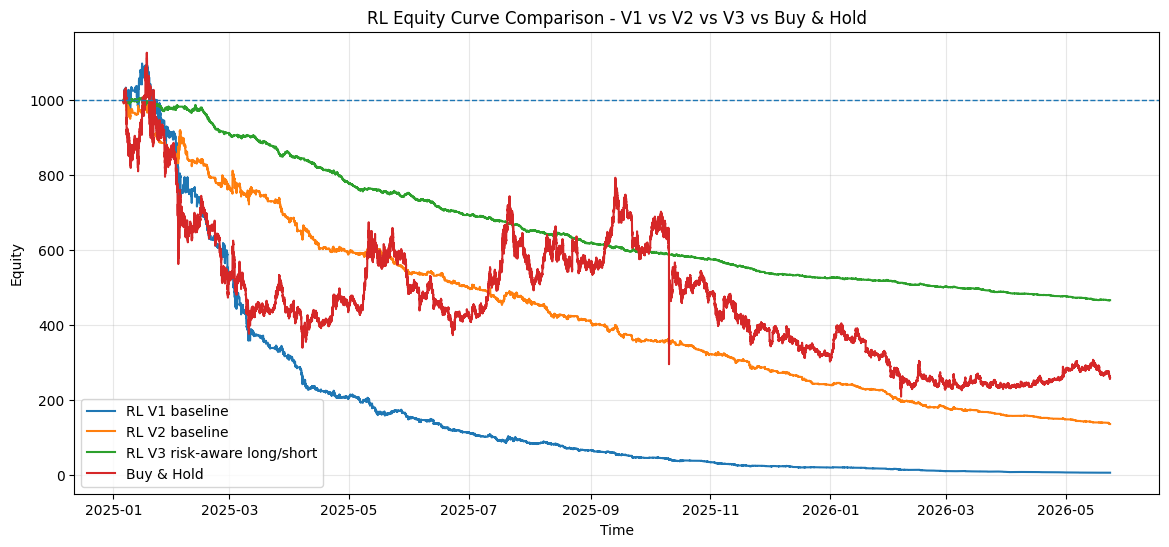

,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,number_of_trades,number_of_trade_events,turnover,...,slippage_applied,position_sizing,cooldown_steps,min_holding_steps,max_portfolio_drawdown_pct,min_position_size_pct,drawdown_position_scaling_floor,regime_filters,shorts_simulated,main_limitation
0,08_baseline_RL,RL baseline,1000.0000,6.646529,-99.335347,-99.398312,-7.406826,NaN,NaN,NaN,...,0.0005,All-in long-only when BUY is executed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Simplified tabular Q-learning baseline with di...
1,09_baseline_RL_v2,RL V2 baseline,1000.0000,136.345883,-86.365412,-86.393880,-6.973000,3108.0,NaN,0.021492,...,0.0005,50% of available cash on BUY,3.0,NaN,NaN,NaN,NaN,NaN,NaN,Tabular Q-learning with simple discretized sta...
2,10_baseline_RL_v3,RL V3 risk-aware long/short,1000.0000,466.361287,-53.363871,-53.726325,-9.826828,NaN,4237.0,0.029298,...,0.0005,"25% base, 10% minimum with drawdown scaling",12.0,12.0,None,0.1,0.5,EMA10/EMA50 trend filter and ATR/close volatil...,True,Tabular Q-learning with simple discretized sta...
3,10_baseline_RL_v3,Buy & Hold,995.7197,258.741572,-74.014618,-81.410760,-0.461721,NaN,NaN,NaN,...,0.0005,"25% base, 10% minimum with drawdown scaling",12.0,12.0,None,0.1,0.5,EMA10/EMA50 trend filter and ATR/close volatil...,True,Tabular Q-learning with simple discretized sta...


In [14]:
# ============================================================
# RL V1, RL V2, RL V3 and Buy & Hold equity comparison
# Se comparan visualmente las curvas de equity de V1, V2, V3 y Buy & Hold usando resultados persistidos y la evaluación actual de V3.
# La tabla resume métricas principales y evita duplicar el benchmark pasivo guardado en versiones anteriores.
# ============================================================

rl_v3_equity = rl_eval_df["equity"].astype(float).reset_index(drop=True)
bh_equity = buy_hold_df["equity"].astype(float).reset_index(drop=True)

comparison_len = min(len(v1_reference_df), len(v2_reference_df), len(rl_v3_equity), len(bh_equity))

v1_reference_aligned = v1_reference_df.tail(comparison_len).reset_index(drop=True)
v2_reference_aligned = v2_reference_df.tail(comparison_len).reset_index(drop=True)
rl_eval_aligned = rl_eval_df.tail(comparison_len).reset_index(drop=True)
rl_v3_equity_aligned = rl_v3_equity.tail(comparison_len).reset_index(drop=True)
bh_equity_aligned = bh_equity.tail(comparison_len).reset_index(drop=True)

comparison_df = pd.DataFrame({
    "rl_v1_equity": v1_reference_aligned["rl_v1_equity"],
    "rl_v2_equity": v2_reference_aligned["rl_v2_equity"],
    "rl_v3_equity": rl_v3_equity_aligned,
    "buy_hold_equity": bh_equity_aligned,
})

if "open_time" in rl_eval_aligned.columns:
    comparison_df["open_time"] = pd.to_datetime(rl_eval_aligned["open_time"])
elif "open_time" in v2_reference_aligned.columns:
    comparison_df["open_time"] = pd.to_datetime(v2_reference_aligned["open_time"])
elif "open_time" in v1_reference_aligned.columns:
    comparison_df["open_time"] = pd.to_datetime(v1_reference_aligned["open_time"])

comparison_df["rl_v1_drawdown"] = compute_drawdown(comparison_df["rl_v1_equity"])
comparison_df["rl_v2_drawdown"] = compute_drawdown(comparison_df["rl_v2_equity"])
comparison_df["rl_v3_drawdown"] = compute_drawdown(comparison_df["rl_v3_equity"])
comparison_df["buy_hold_drawdown"] = compute_drawdown(comparison_df["buy_hold_equity"])

x_axis = comparison_df["open_time"] if "open_time" in comparison_df.columns else comparison_df.index

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_axis, comparison_df["rl_v1_equity"], label="RL V1 baseline")
ax.plot(x_axis, comparison_df["rl_v2_equity"], label="RL V2 baseline")
ax.plot(x_axis, comparison_df["rl_v3_equity"], label="RL V3 risk-aware long/short")
ax.plot(x_axis, comparison_df["buy_hold_equity"], label="Buy & Hold")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("RL Equity Curve Comparison - V1 vs V2 vs V3 vs Buy & Hold")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

summary_rows = [
    summarize_strategy(
        comparison_df["rl_v3_equity"],
        "RL V3 risk-aware long/short",
        action_series=rl_eval_aligned["action"],
        executed_trade_series=rl_eval_aligned["executed_trade"],
        exposure_series=rl_eval_aligned["exposure"],
        invalid_action_series=rl_eval_aligned["invalid_action"],
        forced_exit_series=rl_eval_aligned["forced_exit"],
        exit_reason_series=rl_eval_aligned["exit_reason"],
    ),
    summarize_strategy(comparison_df["buy_hold_equity"], "Buy & Hold"),
]

results_summary_df = pd.DataFrame(summary_rows)
results_summary_df.insert(0, "notebook", NOTEBOOK_ID)
results_summary_df["fees_applied"] = FEE_RATE
results_summary_df["slippage_applied"] = SLIPPAGE_RATE
results_summary_df["position_sizing"] = f"{POSITION_SIZE_PCT:.0%} base, {MIN_POSITION_SIZE_PCT:.0%} minimum with drawdown scaling"
results_summary_df["cooldown_steps"] = COOLDOWN_STEPS
results_summary_df["min_holding_steps"] = MIN_HOLDING_STEPS
results_summary_df["stop_loss_pct"] = STOP_LOSS_PCT
results_summary_df["take_profit_pct"] = TAKE_PROFIT_PCT
results_summary_df["max_portfolio_drawdown_pct"] = MAX_PORTFOLIO_DRAWDOWN_PCT
results_summary_df["min_position_size_pct"] = MIN_POSITION_SIZE_PCT
results_summary_df["drawdown_position_scaling_floor"] = DRAWDOWN_POSITION_SCALING_FLOOR
results_summary_df["trend_strength_threshold_quantile"] = TREND_STRENGTH_THRESHOLD_QUANTILE
results_summary_df["volatility_threshold_quantile"] = VOLATILITY_THRESHOLD_QUANTILE
results_summary_df["drawdown_reward_penalty"] = DRAWDOWN_REWARD_PENALTY
results_summary_df["regime_filters"] = "EMA10/EMA50 trend filter and ATR/close volatility filter"
results_summary_df["shorts_simulated"] = True
results_summary_df["main_limitation"] = "Tabular Q-learning with simple discretized state space, soft drawdown control and simplified short accounting"

reference_summary_df = pd.concat([v1_summary_df, v2_summary_df], ignore_index=True, sort=False)
if "strategy" in reference_summary_df.columns:
    reference_summary_df = reference_summary_df[
        ~reference_summary_df["strategy"].astype(str).str.contains("Buy & Hold", case=False, na=False)
    ].copy()

rl_version_comparison_df = pd.concat(
    [reference_summary_df, results_summary_df],
    ignore_index=True,
    sort=False,
)

preferred_cols = [
    "notebook",
    "strategy",
    "initial_balance",
    "final_balance",
    "return_pct",
    "max_drawdown_pct",
    "sharpe_ratio_approx",
    "number_of_trades",
    "number_of_trade_events",
    "turnover",
    "mean_exposure",
    "max_exposure",
    "invalid_actions",
    "forced_risk_exits",
    "stop_loss_exits",
    "take_profit_exits",
    "long_entries",
    "short_entries",
    "long_exits",
    "short_exits",
    "fees_applied",
    "slippage_applied",
    "position_sizing",
    "cooldown_steps",
    "min_holding_steps",
    "max_portfolio_drawdown_pct",
    "min_position_size_pct",
    "drawdown_position_scaling_floor",
    "regime_filters",
    "shorts_simulated",
    "main_limitation",
]

existing_cols = [col for col in preferred_cols if col in rl_version_comparison_df.columns]
rl_version_comparison_df = rl_version_comparison_df[existing_cols]

display(rl_version_comparison_df)

## Comentarios - Comparación RL V1 vs RL V2 vs RL V3 vs Buy & Hold

La V3 principal mejora claramente la progresión de equity frente a V1 y V2, aunque sigue perdiendo dinero. El resultado final pasa de 6.65 USDT en V1 y 136.35 USDT en V2 a 466.36 USDT en V3. Frente a Buy & Hold, que termina en 258.74 USDT, la V3 reduce bastante el deterioro durante este tramo bajista.

La mejora no debe venderse como rentabilidad, sino como control de pérdidas. La V3 obtiene un retorno de -53.36 %, frente al -86.37 % de V2 y el -74.01 % de Buy & Hold. En términos de curva, la estrategia sigue siendo perdedora, pero deja de comportarse como una demolición acelerada de capital.

Hay una lectura importante: el Sharpe aproximado de V3 sigue siendo negativo y peor que el de Buy & Hold. Esto sugiere que el agente no ha descubierto una política estable de generación de retornos; simplemente limita mejor el daño acumulado mediante filtros, menor exposición, cierres por riesgo y penalización de drawdown.

Por tanto, la conclusión defendible es que V3 mejora el comportamiento operativo del entorno RL, no que resuelva el problema de trading.

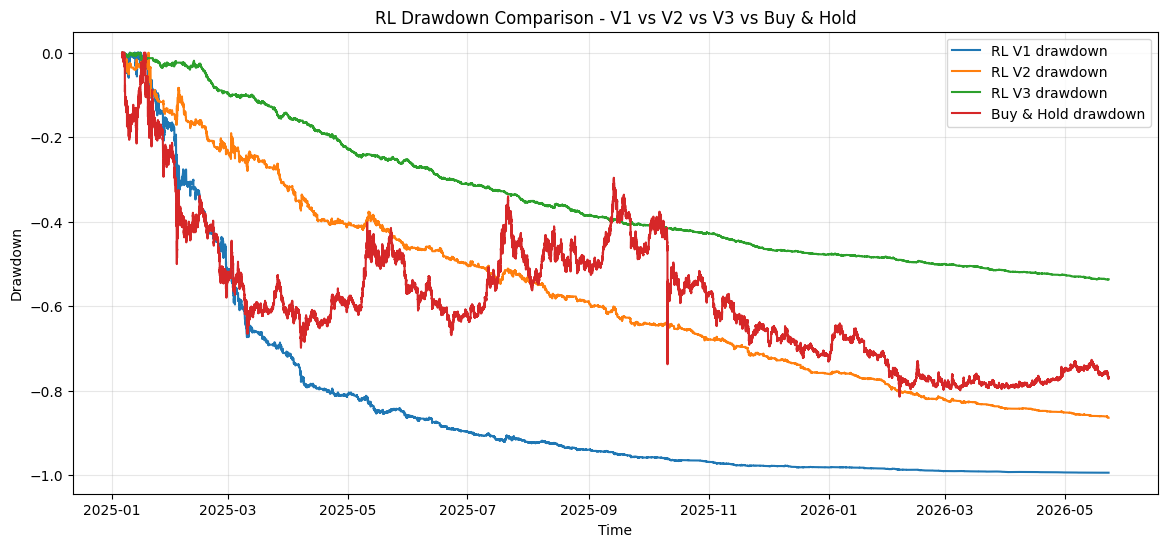

,strategy,max_drawdown_pct,final_drawdown_pct
0,RL V1 baseline,-99.398312,-99.394079
1,RL V2 baseline,-86.393880,-86.393880
2,RL V3 risk-aware long/short,-53.726325,-53.622526
3,Buy & Hold,-81.410760,-77.014546


In [15]:
# ============================================================
# Drawdown comparison
# Se calculan y visualizan los drawdowns acumulados de V1, V2, V3 y Buy & Hold para comparar el riesgo temporal de cada enfoque.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_axis, comparison_df["rl_v1_drawdown"], label="RL V1 drawdown")
ax.plot(x_axis, comparison_df["rl_v2_drawdown"], label="RL V2 drawdown")
ax.plot(x_axis, comparison_df["rl_v3_drawdown"], label="RL V3 drawdown")
ax.plot(x_axis, comparison_df["buy_hold_drawdown"], label="Buy & Hold drawdown")
ax.set_title("RL Drawdown Comparison - V1 vs V2 vs V3 vs Buy & Hold")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

drawdown_summary_df = pd.DataFrame([
    {
        "strategy": "RL V1 baseline",
        "max_drawdown_pct": comparison_df["rl_v1_drawdown"].min() * 100,
        "final_drawdown_pct": comparison_df["rl_v1_drawdown"].iloc[-1] * 100,
    },
    {
        "strategy": "RL V2 baseline",
        "max_drawdown_pct": comparison_df["rl_v2_drawdown"].min() * 100,
        "final_drawdown_pct": comparison_df["rl_v2_drawdown"].iloc[-1] * 100,
    },
    {
        "strategy": "RL V3 risk-aware long/short",
        "max_drawdown_pct": comparison_df["rl_v3_drawdown"].min() * 100,
        "final_drawdown_pct": comparison_df["rl_v3_drawdown"].iloc[-1] * 100,
    },
    {
        "strategy": "Buy & Hold",
        "max_drawdown_pct": comparison_df["buy_hold_drawdown"].min() * 100,
        "final_drawdown_pct": comparison_df["buy_hold_drawdown"].iloc[-1] * 100,
    },
])

display(drawdown_summary_df)

## Comentarios - Drawdown

El drawdown confirma la mejora defensiva de V3. El máximo drawdown baja desde -99.40 % en V1 y -86.39 % en V2 hasta -53.73 % en V3. Buy & Hold alcanza -81.41 %, por lo que la V3 también reduce el deterioro máximo frente al benchmark pasivo.

La diferencia es relevante porque esta versión no usa stop duro de drawdown de cartera. La curva no se congela artificialmente: sigue operando hasta el final del test y aun así mantiene un drawdown bastante menor que V1, V2 y Buy & Hold.

La lectura metodológica es positiva, pero con cautela. El drawdown mejora porque el entorno obliga a operar con menor exposición, filtros de régimen y cierres de riesgo. No demuestra que el agente tenga capacidad predictiva fuerte; demuestra que el diseño del entorno reduce comportamientos destructivos.

In [16]:
# ============================================================
# Action distribution, exposure and trade log
# Se resume la distribución de acciones, operaciones ejecutadas, exposición, tamaño efectivo de posición, filtros activos y motivos de cierre.
# Esto ayuda a interpretar si V3 está usando realmente las nuevas capacidades long/short o si se limita a permanecer inactivo.
# ============================================================

action_distribution_df = (
    rl_eval_aligned["action_label"]
    .value_counts()
    .rename_axis("requested_action")
    .reset_index(name="count")
)
action_distribution_df["pct"] = action_distribution_df["count"] / action_distribution_df["count"].sum() * 100

executed_trade_distribution_df = (
    rl_eval_aligned["executed_trade"]
    .value_counts()
    .rename_axis("executed_trade")
    .reset_index(name="count")
)
executed_trade_distribution_df["pct"] = executed_trade_distribution_df["count"] / executed_trade_distribution_df["count"].sum() * 100

exit_reason_distribution_df = (
    rl_eval_aligned["exit_reason"]
    .fillna("NONE")
    .value_counts()
    .rename_axis("exit_reason")
    .reset_index(name="count")
)

operational_summary_df = pd.DataFrame([{
    "requested_actions": len(rl_eval_aligned),
    "executed_trade_events": int((rl_eval_aligned["executed_trade"] != "HOLD").sum()),
    "invalid_actions": int(rl_eval_aligned["invalid_action"].sum()),
    "forced_risk_exits": int(rl_eval_aligned["forced_exit"].sum()),
    "turnover": int((rl_eval_aligned["executed_trade"] != "HOLD").sum()) / len(rl_eval_aligned),
    "mean_exposure": rl_eval_aligned["exposure"].mean(),
    "max_exposure": rl_eval_aligned["exposure"].max(),
    "mean_effective_position_size_pct": rl_eval_aligned["effective_position_size_pct"].mean() if "effective_position_size_pct" in rl_eval_aligned.columns else np.nan,
    "min_effective_position_size_pct": rl_eval_aligned["effective_position_size_pct"].min() if "effective_position_size_pct" in rl_eval_aligned.columns else np.nan,
    "mean_cooldown_remaining": rl_eval_aligned["cooldown_remaining"].mean(),
    "mean_position_age": rl_eval_aligned["position_age"].mean() if "position_age" in rl_eval_aligned.columns else np.nan,
    "long_filter_share_%": rl_eval_aligned["trend_long_allowed"].mean() * 100,
    "short_filter_share_%": rl_eval_aligned["trend_short_allowed"].mean() * 100,
    "volatility_allowed_share_%": rl_eval_aligned["volatility_allowed"].mean() * 100,
}])

display(action_distribution_df)
display(executed_trade_distribution_df)
display(exit_reason_distribution_df)
display(operational_summary_df)

trade_log_df = pd.DataFrame(test_env.trade_log)

if not trade_log_df.empty and "open_time" in test_df.columns:
    trade_log_df["open_time"] = trade_log_df["step"].apply(lambda idx: test_df.loc[min(idx, len(test_df) - 1), "open_time"])
    trade_log_df = trade_log_df[["open_time", "step", "action", "price", "exit_reason"]]

display(trade_log_df.head(20))
print(f"Executed trade events in test: {len(trade_log_df)}")

,requested_action,count,pct
0,HOLD,140849,97.395844
1,OPEN_LONG,1063,0.735055
2,OPEN_SHORT,1056,0.730215
3,CLOSE_SHORT,839,0.580161
4,CLOSE_LONG,808,0.558725


,executed_trade,count,pct
0,HOLD,140378,97.070152
1,CLOSE_LONG,1063,0.735055
2,OPEN_LONG,1063,0.735055
3,OPEN_SHORT,1056,0.730215
4,CLOSE_SHORT,1055,0.729523


,exit_reason,count
0,NONE,144112
1,STOP_LOSS,418
2,TAKE_PROFIT,85


,requested_actions,executed_trade_events,invalid_actions,forced_risk_exits,turnover,mean_exposure,max_exposure,mean_effective_position_size_pct,min_effective_position_size_pct,mean_cooldown_remaining,mean_position_age,long_filter_share_%,short_filter_share_%,volatility_allowed_share_%
0,144615,4237,0,503,0.029298,0.032301,0.252836,0.147129,0.1,2.247768,1.975922,20.82564,21.730802,76.225841


,open_time,step,action,price,exit_reason
0,2025-01-06 07:55:00,12,OPEN_SHORT,0.38321,None
1,2025-01-06 09:25:00,30,CLOSE_SHORT,0.38326,None
2,2025-01-07 08:35:00,308,OPEN_LONG,0.39540,None
3,2025-01-07 10:00:00,325,CLOSE_LONG,0.39206,None
4,2025-01-07 11:35:00,344,OPEN_SHORT,0.38732,None
5,2025-01-07 14:05:00,374,CLOSE_SHORT,0.38728,None
6,2025-01-07 23:50:00,491,OPEN_SHORT,0.34830,None
7,2025-01-08 00:15:00,496,CLOSE_SHORT,0.35268,STOP_LOSS
8,2025-01-08 06:25:00,570,OPEN_SHORT,0.34800,None
9,2025-01-08 06:55:00,576,CLOSE_SHORT,0.34086,TAKE_PROFIT


Executed trade events in test: 4237


## Comentarios - Distribución de acciones y operaciones

La distribución de acciones muestra una V3 mucho menos impulsiva que la versión anterior. El agente mantiene HOLD en el 97.07 % de los pasos y ejecuta 4.237 eventos de trading sobre 144.615 velas, es decir, una actividad del 2.93 % del test.

La operativa queda bastante equilibrada entre long y short: 1.063 entradas long y 1.056 entradas short. Esto confirma que el agente sí está usando el espacio de acciones ampliado, aunque la ablation posterior muestra que las shorts no mejoran el resultado global en esta configuración.

Los cierres forzados por riesgo son relevantes: aparecen 503 forced risk exits, de los cuales 418 son stop-loss y 85 take-profit. Esto indica que buena parte de la gestión de salida procede de las reglas del entorno, no únicamente de decisiones discrecionales aprendidas por Q-learning.

La exposición media es baja, 0.0323, y el tamaño efectivo medio de posición es 14.71 %, con mínimo del 10 %. Esto explica parte de la estabilización: V3 no gana por operar mucho, sino por exponerse poco y cortar parte de las operaciones mediante reglas de riesgo.

## Ablation - Dynamic position sizing vs fixed sizing

La V3 incorpora varias mejoras a la vez: filtros de régimen, shorts simuladas, cooldown más estricto, mínimo de permanencia, stop-loss/take-profit, reward penalizado por drawdown y position sizing dinámico.

El position sizing dinámico puede mejorar la curva de forma defensiva aunque la política no sea mejor. Por eso se añade una prueba de ablación con tres variantes:

- V3 completa con position sizing dinámico
- V3 sin position sizing dinámico, manteniendo long/short y filtros
- V3 sin position sizing dinámico y sin shorts, para comprobar cuánto aporta la ampliación long/short

La comparación no sustituye a la evaluación principal de V3, pero ayuda a interpretar si la mejora procede del comportamiento aprendido o de una reducción mecánica de exposición.

In [17]:
# ============================================================
# V3 ablation experiment definition
# Se definen funciones auxiliares para reentrenar y evaluar variantes de V3 con la misma lógica de Q-learning.
# El objetivo es aislar el impacto del position sizing dinámico frente al resto de cambios introducidos en V3.
# ============================================================

ABLATION_EPISODES = N_EPISODES
ABLATION_MAX_TRAIN_EPISODE_STEPS = MAX_TRAIN_EPISODE_STEPS


def build_v3_env_for_ablation(data, variant_config, random_start, max_episode_steps, seed):
    return DogeTradingEnvV3(
        data,
        feature_cols,
        initial_balance=INITIAL_BALANCE,
        fee_rate=FEE_RATE,
        slippage_rate=SLIPPAGE_RATE,
        position_size_pct=variant_config["position_size_pct"],
        min_position_size_pct=variant_config["min_position_size_pct"],
        drawdown_position_scaling_floor=variant_config["drawdown_position_scaling_floor"],
        cooldown_steps=variant_config["cooldown_steps"],
        min_holding_steps=variant_config["min_holding_steps"],
        trade_reward_penalty=variant_config["trade_reward_penalty"],
        invalid_action_penalty=INVALID_ACTION_PENALTY,
        drawdown_reward_penalty=variant_config["drawdown_reward_penalty"],
        stop_loss_pct=variant_config["stop_loss_pct"],
        take_profit_pct=variant_config["take_profit_pct"],
        max_portfolio_drawdown_pct=None,
        random_start=random_start,
        max_episode_steps=max_episode_steps,
        seed=seed,
    )


def train_v3_ablation_variant(variant_config):
    np.random.seed(RANDOM_STATE)

    train_env_variant = build_v3_env_for_ablation(
        variant_config["train_data"],
        variant_config,
        random_start=True,
        max_episode_steps=ABLATION_MAX_TRAIN_EPISODE_STEPS,
        seed=RANDOM_STATE + variant_config["seed_offset"],
    )

    variant_q_table = defaultdict(lambda: np.zeros(train_env_variant.action_space.n, dtype=np.float64))
    variant_episode_metrics = []
    epsilon = epsilon_start

    for episode in range(1, ABLATION_EPISODES + 1):
        obs, info = train_env_variant.reset(seed=RANDOM_STATE + variant_config["seed_offset"] + episode)
        state = discretize_observation(obs)
        total_reward = 0.0
        done = False
        steps = 0

        while not done:
            valid_actions = train_env_variant.get_valid_actions()
            action = choose_action(variant_q_table, state, epsilon, valid_actions, train_env_variant.action_space.n)
            next_obs, reward, terminated, truncated, info = train_env_variant.step(action)
            next_state = discretize_observation(next_obs)

            next_valid_actions = train_env_variant.get_valid_actions()
            best_next_q = np.max(variant_q_table[next_state][next_valid_actions])
            variant_q_table[state][action] += alpha * (reward + gamma * best_next_q - variant_q_table[state][action])

            state = next_state
            total_reward += reward
            steps += 1
            done = terminated or truncated

        episode_trade_log_df = pd.DataFrame(train_env_variant.trade_log)

        variant_episode_metrics.append({
            "variant_id": variant_config["variant_id"],
            "variant_label": variant_config["label"],
            "episode": episode,
            "steps": steps,
            "total_reward": total_reward,
            "final_equity": info["equity"],
            "epsilon": epsilon,
            "num_trade_events": len(train_env_variant.trade_log),
            "long_entries": int((episode_trade_log_df["action"] == "OPEN_LONG").sum()) if not episode_trade_log_df.empty else 0,
            "short_entries": int((episode_trade_log_df["action"] == "OPEN_SHORT").sum()) if not episode_trade_log_df.empty else 0,
            "forced_risk_exits": train_env_variant.forced_exit_count,
            "invalid_actions": train_env_variant.invalid_action_count,
            "mean_exposure": np.mean(train_env_variant.exposure_history) if train_env_variant.exposure_history else 0.0,
            "mean_effective_position_size_pct": np.mean(train_env_variant.effective_position_size_history) if train_env_variant.effective_position_size_history else 0.0,
            "max_drawdown": np.min(train_env_variant.drawdown_history) if train_env_variant.drawdown_history else 0.0,
        })

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    return variant_q_table, pd.DataFrame(variant_episode_metrics)


def evaluate_v3_ablation_variant(variant_config, variant_q_table):
    test_env_variant = build_v3_env_for_ablation(
        variant_config["test_data"],
        variant_config,
        random_start=False,
        max_episode_steps=None,
        seed=RANDOM_STATE + variant_config["seed_offset"],
    )

    obs, info = test_env_variant.reset(seed=RANDOM_STATE + variant_config["seed_offset"])
    state = discretize_observation(obs)
    eval_records = []
    done = False

    while not done:
        valid_actions = test_env_variant.get_valid_actions()
        action = choose_action(variant_q_table, state, epsilon=0.0, valid_actions=valid_actions, n_actions=test_env_variant.action_space.n)
        next_obs, reward, terminated, truncated, info = test_env_variant.step(action)
        next_state = discretize_observation(next_obs)

        record = {
            "variant_id": variant_config["variant_id"],
            "variant_label": variant_config["label"],
            "step": test_env_variant.current_step,
            "action": action,
            "action_label": DogeTradingEnvV3.ACTION_LABELS.get(action, "UNKNOWN"),
            "executed_action": info["executed_action"],
            "executed_trade": info["executed_trade"],
            "invalid_action": info["invalid_action"],
            "forced_exit": info["forced_exit"],
            "exit_reason": info["exit_reason"],
            "price": info["price"],
            "equity": info["equity"],
            "reward": reward,
            "position_side": info["position_side"],
            "exposure": info["exposure"],
            "effective_position_size_pct": info["effective_position_size_pct"],
            "drawdown": info["drawdown"],
            "cooldown_remaining": info["cooldown_remaining"],
            "position_age": info["position_age"],
            "trend_long_allowed": info["trend_long_allowed"],
            "trend_short_allowed": info["trend_short_allowed"],
            "volatility_allowed": info["volatility_allowed"],
        }

        if "open_time" in variant_config["test_data"].columns:
            record["open_time"] = variant_config["test_data"].loc[min(test_env_variant.current_step, len(variant_config["test_data"]) - 1), "open_time"]

        eval_records.append(record)
        state = next_state
        done = terminated or truncated

    variant_eval_df = pd.DataFrame(eval_records)

    if "open_time" in variant_eval_df.columns:
        variant_eval_df["open_time"] = pd.to_datetime(variant_eval_df["open_time"])

    return variant_eval_df, test_env_variant


def summarize_v3_ablation_variant(variant_config, variant_eval_df, variant_training_df):
    summary = summarize_strategy(
        variant_eval_df["equity"],
        variant_config["label"],
        action_series=variant_eval_df["action"],
        executed_trade_series=variant_eval_df["executed_trade"],
        exposure_series=variant_eval_df["exposure"],
        invalid_action_series=variant_eval_df["invalid_action"],
        forced_exit_series=variant_eval_df["forced_exit"],
        exit_reason_series=variant_eval_df["exit_reason"],
    )

    summary.update({
        "variant_id": variant_config["variant_id"],
        "dynamic_position_sizing": variant_config["dynamic_position_sizing"],
        "shorts_enabled": variant_config["shorts_enabled"],
        "base_position_size_pct": variant_config["position_size_pct"],
        "min_position_size_pct": variant_config["min_position_size_pct"],
        "drawdown_position_scaling_floor": variant_config["drawdown_position_scaling_floor"],
        "mean_effective_position_size_pct": variant_eval_df["effective_position_size_pct"].mean(),
        "min_effective_position_size_pct": variant_eval_df["effective_position_size_pct"].min(),
        "max_effective_position_size_pct": variant_eval_df["effective_position_size_pct"].max(),
        "mean_drawdown_pct": variant_eval_df["drawdown"].mean() * 100,
        "training_best_final_equity": variant_training_df["final_equity"].max() if len(variant_training_df) > 0 else np.nan,
        "training_mean_final_equity_last_10": variant_training_df.tail(10)["final_equity"].mean() if len(variant_training_df) > 0 else np.nan,
        "ablation_episodes": ABLATION_EPISODES,
    })

    return summary


In [18]:
# ============================================================
# Run V3 ablation variants
# Se reentrenan tres variantes para comprobar si la mejora de V3 depende del position sizing dinámico.
# La variante fixed-size mantiene los demás cambios de V3, por lo que permite evaluar si filtros, reward defensivo y shorts mejoran por sí solos.
# ============================================================

train_scaled_long_only_df = train_scaled_df.copy()
test_scaled_long_only_df = test_scaled_df.copy()
train_scaled_long_only_df["trend_short_filter"] = False
test_scaled_long_only_df["trend_short_filter"] = False

base_ablation_params = {
    "position_size_pct": POSITION_SIZE_PCT,
    "cooldown_steps": COOLDOWN_STEPS,
    "min_holding_steps": MIN_HOLDING_STEPS,
    "trade_reward_penalty": TRADE_REWARD_PENALTY,
    "drawdown_reward_penalty": DRAWDOWN_REWARD_PENALTY,
    "stop_loss_pct": STOP_LOSS_PCT,
    "take_profit_pct": TAKE_PROFIT_PCT,
}

ablation_variant_configs = [
    {
        **base_ablation_params,
        "variant_id": "v3_dynamic_long_short",
        "label": "V3 dynamic sizing long/short",
        "dynamic_position_sizing": True,
        "shorts_enabled": True,
        "min_position_size_pct": MIN_POSITION_SIZE_PCT,
        "drawdown_position_scaling_floor": DRAWDOWN_POSITION_SCALING_FLOOR,
        "train_data": train_scaled_df,
        "test_data": test_scaled_df,
        "seed_offset": 0,
    },
    {
        **base_ablation_params,
        "variant_id": "v3_fixed_size_long_short",
        "label": "V3 fixed size long/short",
        "dynamic_position_sizing": False,
        "shorts_enabled": True,
        "min_position_size_pct": POSITION_SIZE_PCT,
        "drawdown_position_scaling_floor": 1.0,
        "train_data": train_scaled_df,
        "test_data": test_scaled_df,
        "seed_offset": 1000,
    },
    {
        **base_ablation_params,
        "variant_id": "v3_fixed_size_long_only",
        "label": "V3 fixed size long-only",
        "dynamic_position_sizing": False,
        "shorts_enabled": False,
        "min_position_size_pct": POSITION_SIZE_PCT,
        "drawdown_position_scaling_floor": 1.0,
        "train_data": train_scaled_long_only_df,
        "test_data": test_scaled_long_only_df,
        "seed_offset": 2000,
    },
]

ablation_summary_rows = []
ablation_eval_frames = []
ablation_training_frames = []
ablation_q_tables = {}

for variant_config in ablation_variant_configs:
    print(f"Running ablation variant: {variant_config['label']}")
    variant_q_table, variant_training_df = train_v3_ablation_variant(variant_config)
    variant_eval_df, variant_test_env = evaluate_v3_ablation_variant(variant_config, variant_q_table)

    ablation_q_tables[variant_config["variant_id"]] = variant_q_table
    ablation_training_frames.append(variant_training_df)
    ablation_eval_frames.append(variant_eval_df)
    ablation_summary_rows.append(summarize_v3_ablation_variant(variant_config, variant_eval_df, variant_training_df))

ablation_summary_df = pd.DataFrame(ablation_summary_rows)
ablation_training_metrics_df = pd.concat(ablation_training_frames, ignore_index=True, sort=False)
ablation_eval_df = pd.concat(ablation_eval_frames, ignore_index=True, sort=False)

ablation_preferred_cols = [
    "variant_id",
    "strategy",
    "dynamic_position_sizing",
    "shorts_enabled",
    "initial_balance",
    "final_balance",
    "return_pct",
    "max_drawdown_pct",
    "sharpe_ratio_approx",
    "number_of_trade_events",
    "turnover",
    "mean_exposure",
    "max_exposure",
    "mean_effective_position_size_pct",
    "min_effective_position_size_pct",
    "max_effective_position_size_pct",
    "forced_risk_exits",
    "stop_loss_exits",
    "take_profit_exits",
    "long_entries",
    "short_entries",
    "long_exits",
    "short_exits",
    "training_best_final_equity",
    "training_mean_final_equity_last_10",
    "ablation_episodes",
]

ablation_summary_df = ablation_summary_df[[col for col in ablation_preferred_cols if col in ablation_summary_df.columns]]
display(ablation_summary_df)


Running ablation variant: V3 dynamic sizing long/short
Running ablation variant: V3 fixed size long/short
Running ablation variant: V3 fixed size long-only


,variant_id,strategy,dynamic_position_sizing,shorts_enabled,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,number_of_trade_events,...,forced_risk_exits,stop_loss_exits,take_profit_exits,long_entries,short_entries,long_exits,short_exits,training_best_final_equity,training_mean_final_equity_last_10,ablation_episodes
0,v3_dynamic_long_short,V3 dynamic sizing long/short,True,True,1000.0,466.361287,-53.363871,-53.726325,-9.826828,4237,...,503,418,85,1063,1056,1063,1055,1004.904358,987.446657,50
1,v3_fixed_size_long_short,V3 fixed size long/short,False,True,1000.0,257.018853,-74.298115,-74.685114,-11.193767,4356,...,485,398,87,1084,1094,1084,1094,1013.180067,986.258618,50
2,v3_fixed_size_long_only,V3 fixed size long-only,False,False,1000.0,470.364877,-52.963512,-53.009094,-8.821745,2080,...,267,220,47,1040,0,1040,0,1009.304461,988.448128,50


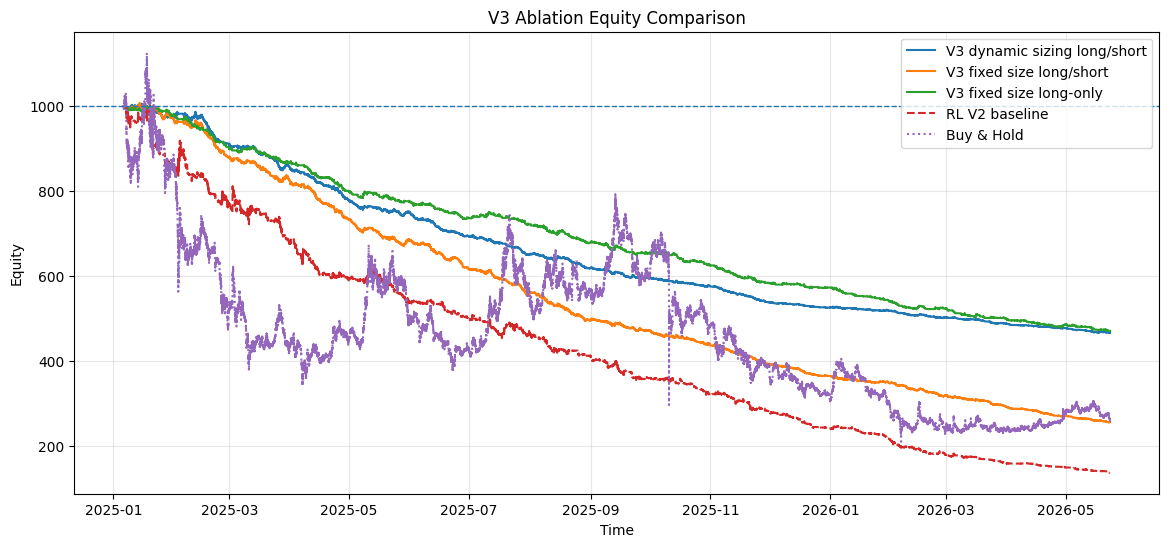

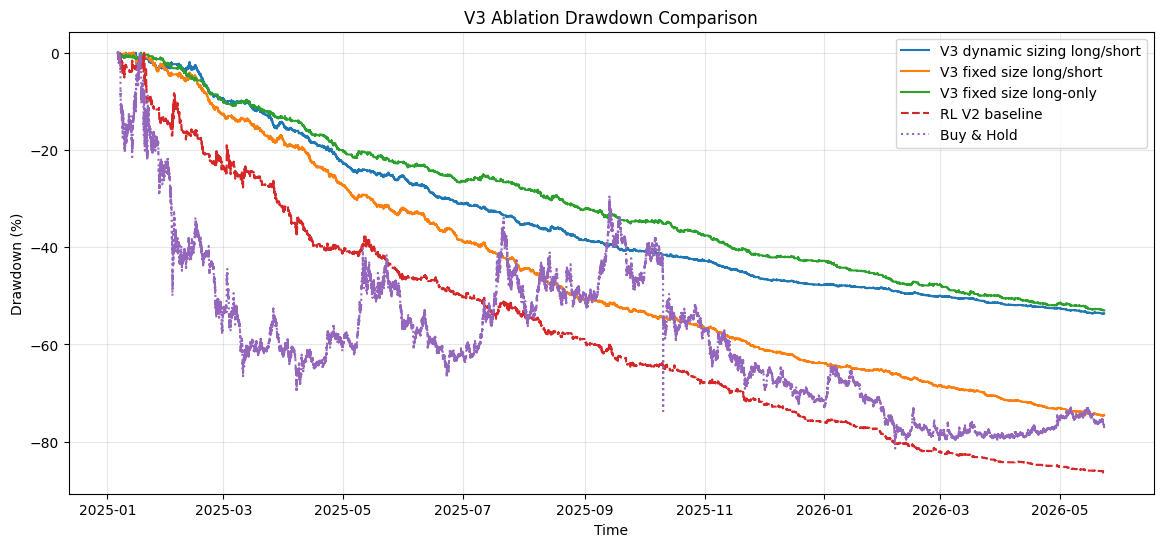

In [19]:
# ============================================================
# Ablation equity and drawdown comparison
# Se visualiza la evolución de equity y drawdown de las variantes V3 para interpretar el peso del position sizing dinámico.
# También se añaden V2 y Buy & Hold como referencias externas para mantener continuidad con la comparación progresiva del bloque RL.
# ============================================================

ablation_curve_frames = []

for variant_id, variant_eval_part in ablation_eval_df.groupby("variant_id", sort=False):
    variant_curve = variant_eval_part.reset_index(drop=True).copy()
    variant_curve["ablation_step"] = np.arange(len(variant_curve))
    variant_curve["equity_drawdown"] = compute_drawdown(variant_curve["equity"])
    ablation_curve_frames.append(
        variant_curve[
            [
                "variant_id",
                "variant_label",
                "ablation_step",
                "open_time",
                "equity",
                "equity_drawdown",
            ] if "open_time" in variant_curve.columns else [
                "variant_id",
                "variant_label",
                "ablation_step",
                "equity",
                "equity_drawdown",
            ]
        ]
    )

ablation_curves_df = pd.concat(ablation_curve_frames, ignore_index=True, sort=False)
ablation_len = ablation_curves_df.groupby("variant_id").size().min()

v2_ablation_reference = v2_reference_df.tail(ablation_len).reset_index(drop=True)
bh_ablation_reference = buy_hold_df["equity"].tail(ablation_len).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

for variant_label, variant_curve in ablation_curves_df.groupby("variant_label", sort=False):
    variant_curve_plot = variant_curve.tail(ablation_len).reset_index(drop=True)
    x_axis = variant_curve_plot["open_time"] if "open_time" in variant_curve_plot.columns else variant_curve_plot["ablation_step"]
    ax.plot(x_axis, variant_curve_plot["equity"], label=variant_label)

reference_x_axis = x_axis
ax.plot(reference_x_axis, v2_ablation_reference["rl_v2_equity"], label="RL V2 baseline", linestyle="--")
ax.plot(reference_x_axis, bh_ablation_reference, label="Buy & Hold", linestyle=":")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("V3 Ablation Equity Comparison")
ax.set_xlabel("Time" if "open_time" in ablation_curves_df.columns else "Test candle")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))

for variant_label, variant_curve in ablation_curves_df.groupby("variant_label", sort=False):
    variant_curve_plot = variant_curve.tail(ablation_len).reset_index(drop=True)
    x_axis = variant_curve_plot["open_time"] if "open_time" in variant_curve_plot.columns else variant_curve_plot["ablation_step"]
    ax.plot(x_axis, variant_curve_plot["equity_drawdown"] * 100, label=variant_label)

ax.plot(reference_x_axis, compute_drawdown(v2_ablation_reference["rl_v2_equity"]) * 100, label="RL V2 baseline", linestyle="--")
ax.plot(reference_x_axis, compute_drawdown(bh_ablation_reference) * 100, label="Buy & Hold", linestyle=":")
ax.set_title("V3 Ablation Drawdown Comparison")
ax.set_xlabel("Time" if "open_time" in ablation_curves_df.columns else "Test candle")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## Comentarios - Ablation de position sizing

La ablation aclara el punto crítico del experimento: el position sizing dinámico no es la única explicación de la mejora de V3, pero sí amortigua el daño cuando las shorts están activadas.

La variante principal `V3 dynamic sizing long/short` termina en 466.36 USDT. La variante `V3 fixed size long-only`, sin dynamic sizing y sin shorts, termina en 470.36 USDT. Estos dos resultados son prácticamente equivalentes, por lo que la mejora frente a V2 no depende necesariamente de reducir exposición de forma dinámica durante el drawdown.

La variante problemática es `V3 fixed size long/short`, que cae hasta 257.02 USDT. Esto queda muy cerca de Buy & Hold y bastante por debajo de las otras dos variantes V3. La lectura más clara es que las shorts simuladas no están finas: cuando se usan con tamaño fijo, degradan mucho el resultado.

Por tanto, el dynamic sizing no parece ser “la trampa” que explica toda la mejora. Más bien funciona como airbag para una rama long/short débil. La variante más limpia para defender metodología es la fixed-size long-only: conserva filtros de régimen, reward defensivo, cooldown, mínimo de permanencia y stop-loss/take-profit, pero evita dos posibles confounds importantes, shorts simuladas y reducción dinámica de exposición.

En definitiva, las shorts se probaron porque eran una mejora lógica en un tramo bajista, pero en este entorno tabular no aportaron valor robusto. La mejora real parece venir de las restricciones de riesgo y de actividad, no de ampliar el espacio de acciones hacia short.

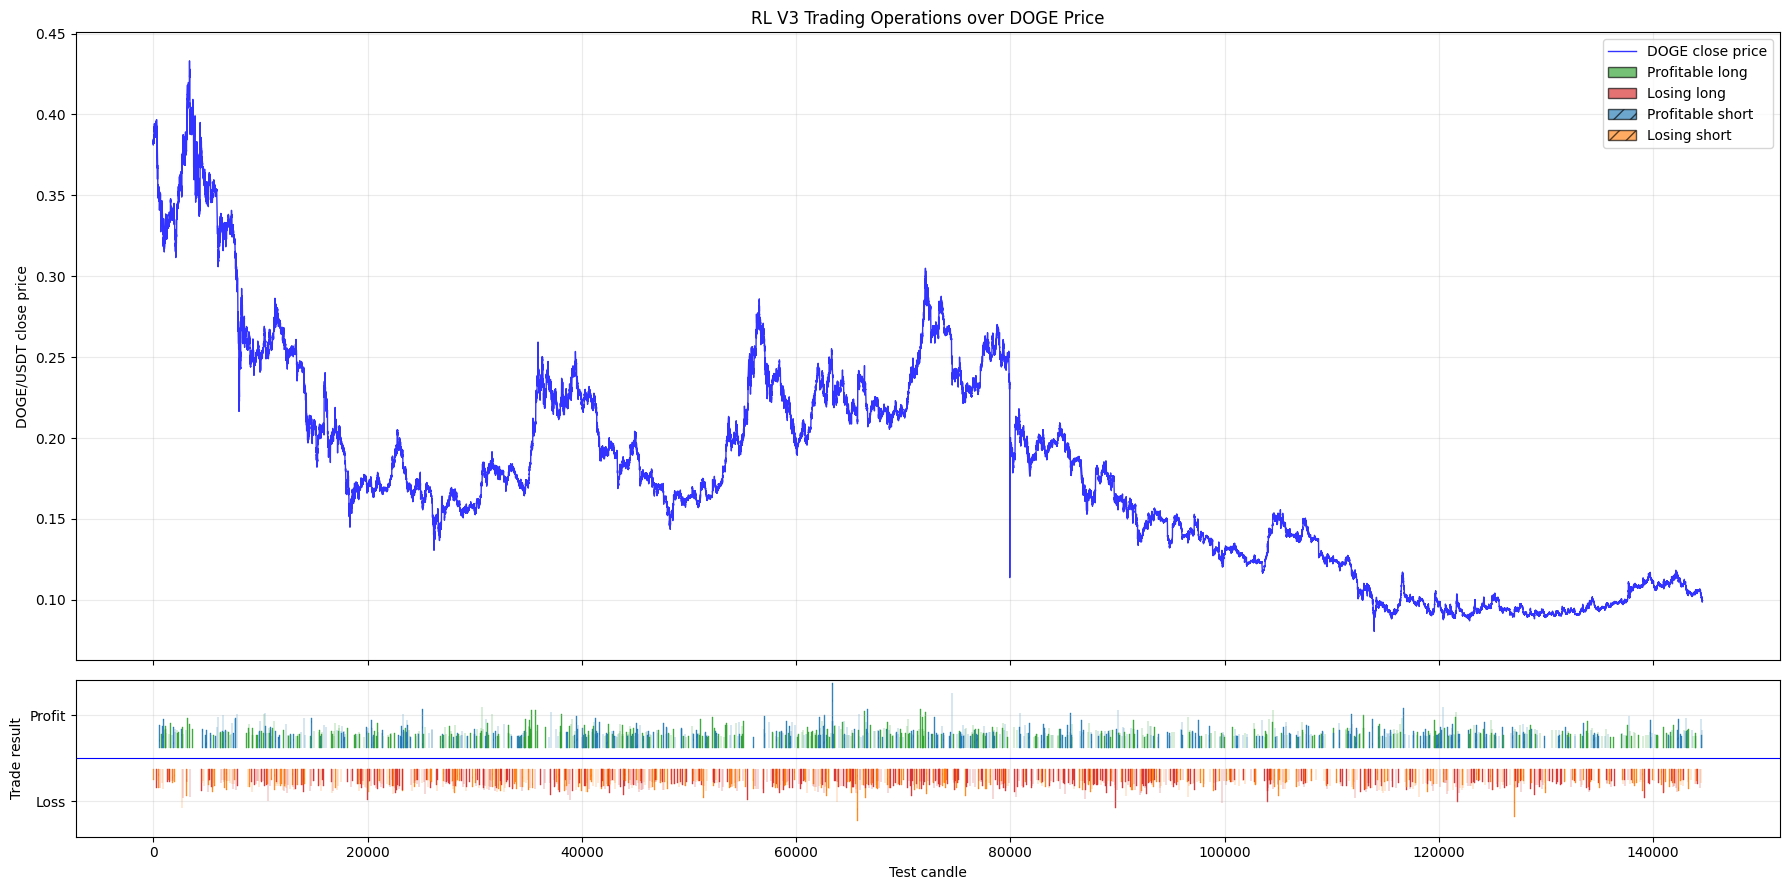

First RL V3 trade events:


,open_time,step,price,action_label,executed_trade,exit_reason,equity,reward,position_side,exposure,drawdown,cooldown_remaining,position_age,invalid_action,forced_exit,trend_long_allowed,trend_short_allowed,volatility_allowed
12,2025-01-06 08:00:00,13,0.38397,OPEN_SHORT,OPEN_SHORT,None,999.379499,-0.001023,-1,0.250155,-0.000621,12,1,False,False,False,True,True
30,2025-01-06 09:30:00,31,0.38399,CLOSE_SHORT,CLOSE_SHORT,None,999.467473,-0.000779,0,0.000000,-0.001163,12,0,False,False,False,False,True
308,2025-01-07 08:40:00,309,0.39589,OPEN_LONG,OPEN_LONG,None,999.402135,-0.000469,1,0.249602,-0.001229,12,1,False,False,True,False,True
325,2025-01-07 10:05:00,326,0.39200,CLOSE_LONG,CLOSE_LONG,None,996.618393,-0.000784,0,0.000000,-0.004011,12,0,False,False,False,False,True
344,2025-01-07 11:40:00,345,0.38513,OPEN_SHORT,OPEN_SHORT,None,997.895776,0.000873,-1,0.248478,-0.002734,12,1,False,False,False,True,True
374,2025-01-07 14:10:00,375,0.38571,CLOSE_SHORT,CLOSE_SHORT,None,996.148239,-0.000787,0,0.000000,-0.004480,12,0,False,False,False,False,True
491,2025-01-07 23:55:00,492,0.34800,OPEN_SHORT,OPEN_SHORT,None,996.237694,-0.000323,-1,0.248634,-0.004391,12,1,False,False,False,True,True
496,2025-01-08 00:20:00,497,0.35131,HOLD,CLOSE_SHORT,STOP_LOSS,992.534959,-0.000803,0,0.000000,-0.008091,12,0,False,True,False,True,False
570,2025-01-08 06:30:00,571,0.34802,OPEN_SHORT,OPEN_SHORT,None,992.398043,-0.000563,-1,0.247607,-0.008228,12,1,False,False,False,True,False
576,2025-01-08 07:00:00,577,0.34315,HOLD,CLOSE_SHORT,TAKE_PROFIT,997.090260,-0.000773,0,0.000000,-0.003539,12,0,False,True,False,True,False


Last RL V3 trade events:


,open_time,step,price,action_label,executed_trade,exit_reason,equity,reward,position_side,exposure,drawdown,cooldown_remaining,position_age,invalid_action,forced_exit,trend_long_allowed,trend_short_allowed,volatility_allowed
144376,2026-05-22 14:20:00,144377,0.10544,HOLD,CLOSE_LONG,STOP_LOSS,465.698704,-0.002159,0,0.000000,-0.536884,12,0,False,True,False,False,True
144453,2026-05-22 20:45:00,144454,0.10397,OPEN_SHORT,OPEN_SHORT,None,465.621646,-0.002176,-1,0.100017,-0.536961,12,1,False,False,False,True,True
144467,2026-05-22 21:55:00,144468,0.10433,CLOSE_SHORT,CLOSE_SHORT,None,465.376658,-0.002162,0,0.000000,-0.537204,12,0,False,False,False,False,True
144481,2026-05-22 23:05:00,144482,0.10372,OPEN_SHORT,OPEN_SHORT,None,465.330967,-0.002110,-1,0.100010,-0.537250,12,1,False,False,False,True,True
144496,2026-05-23 00:20:00,144497,0.10156,HOLD,CLOSE_SHORT,TAKE_PROFIT,466.308125,-0.002155,0,0.000000,-0.536278,12,0,False,True,False,True,True
144514,2026-05-23 01:50:00,144515,0.10184,OPEN_SHORT,OPEN_SHORT,None,466.266508,-0.002098,-1,0.100009,-0.536320,12,1,False,False,False,True,True
144546,2026-05-23 04:30:00,144547,0.10159,CLOSE_SHORT,CLOSE_SHORT,None,466.361614,-0.002158,0,0.000000,-0.536225,12,0,False,False,False,False,True
144568,2026-05-23 06:20:00,144569,0.10089,OPEN_SHORT,OPEN_SHORT,None,466.370626,-0.001989,-1,0.099998,-0.536216,12,1,False,False,False,True,True
144585,2026-05-23 07:45:00,144586,0.10008,CLOSE_SHORT,CLOSE_SHORT,None,466.328475,-0.002159,0,0.000000,-0.536258,12,0,False,False,False,True,True
144602,2026-05-23 09:10:00,144603,0.09960,OPEN_SHORT,OPEN_SHORT,None,466.337905,-0.001989,-1,0.099998,-0.536249,12,1,False,False,False,True,True


Completed RL V3 trades:


,side,entry_idx,exit_idx,entry_time,exit_time,entry_price,exit_price,pnl_pct,duration_bars,exit_reason,result
0,SHORT,12,30,2025-01-06 08:00:00,2025-01-06 09:30:00,0.38397,0.38399,-0.005208,18,None,LOSS
1,LONG,308,325,2025-01-07 08:40:00,2025-01-07 10:05:00,0.39589,0.39200,-0.982596,17,None,LOSS
2,SHORT,344,374,2025-01-07 11:40:00,2025-01-07 14:10:00,0.38513,0.38571,-0.150372,30,None,LOSS
3,SHORT,491,496,2025-01-07 23:55:00,2025-01-08 00:20:00,0.34800,0.35131,-0.942188,5,STOP_LOSS,LOSS
4,SHORT,570,576,2025-01-08 06:30:00,2025-01-08 07:00:00,0.34802,0.34315,1.419204,6,TAKE_PROFIT,PROFIT
...,...,...,...,...,...,...,...,...,...,...,...
2113,LONG,144363,144376,2026-05-22 13:15:00,2026-05-22 14:20:00,0.10656,0.10544,-1.051051,13,STOP_LOSS,LOSS
2114,SHORT,144453,144467,2026-05-22 20:45:00,2026-05-22 21:55:00,0.10397,0.10433,-0.345059,14,None,LOSS
2115,SHORT,144481,144496,2026-05-22 23:05:00,2026-05-23 00:20:00,0.10372,0.10156,2.126822,15,TAKE_PROFIT,PROFIT
2116,SHORT,144514,144546,2026-05-23 01:50:00,2026-05-23 04:30:00,0.10184,0.10159,0.246087,32,None,PROFIT


Open position status at the end of the test:


,has_open_position_at_end,open_side,open_entry_idx,open_entry_time,open_entry_price
0,True,SHORT,144602,2026-05-23 09:10:00,0.0996


,num_test_candles,num_trade_events,trade_event_share_%,num_long_entries,num_short_entries,num_long_exits,num_short_exits,num_hold_events,num_completed_trades,profitable_trades,...,avg_trade_pnl_%,median_trade_pnl_%,avg_trade_duration_bars,stop_loss_exits,take_profit_exits,avg_candles_per_trade_event,mean_exposure,max_exposure,mean_effective_position_size_pct,min_effective_position_size_pct
0,144615,4237,2.929848,1063,1056,1063,1055,140378,2118,1038,...,0.005907,-0.019411,15.076487,418,85,34.131461,0.032301,0.252836,0.147129,0.1


In [20]:
# ============================================================
# Trading operations timeline
# Esta visualización muestra operaciones completas ejecutadas por RL V3 usando un panel de precio y un panel de resultados operativos.
# Cada bloque representa una operación desde entrada hasta salida; el color indica resultado y el tramado permite distinguir operaciones short.
# ============================================================

import matplotlib.patches as patches

action_timeline_df = rl_eval_aligned.copy().reset_index(drop=True)
price_series = action_timeline_df["price"].astype(float).reset_index(drop=True)

if "open_time" in action_timeline_df.columns:
    action_timeline_df["open_time"] = pd.to_datetime(action_timeline_df["open_time"])

trade_rows = []
current_trade = None

for i, row in action_timeline_df.iterrows():
    action = row["executed_trade"]
    price_i = float(row["price"])
    time_i = row["open_time"] if "open_time" in action_timeline_df.columns else None

    if action in ["OPEN_LONG", "OPEN_SHORT"]:
        current_trade = {
            "side": "LONG" if action == "OPEN_LONG" else "SHORT",
            "entry_idx": i,
            "entry_time": time_i,
            "entry_price": price_i,
        }

    elif action in ["CLOSE_LONG", "CLOSE_SHORT"] and current_trade is not None:
        exit_idx = i
        exit_price = price_i
        exit_time = time_i

        if current_trade["side"] == "LONG":
            pnl_pct = (exit_price / current_trade["entry_price"] - 1) * 100
        else:
            pnl_pct = (current_trade["entry_price"] / exit_price - 1) * 100

        trade_rows.append({
            "side": current_trade["side"],
            "entry_idx": current_trade["entry_idx"],
            "exit_idx": exit_idx,
            "entry_time": current_trade["entry_time"],
            "exit_time": exit_time,
            "entry_price": current_trade["entry_price"],
            "exit_price": exit_price,
            "pnl_pct": pnl_pct,
            "duration_bars": exit_idx - current_trade["entry_idx"],
            "exit_reason": row["exit_reason"],
            "result": "PROFIT" if pnl_pct >= 0 else "LOSS",
        })

        current_trade = None

trades_v3_df = pd.DataFrame(trade_rows)

open_position_summary_df = pd.DataFrame([{
    "has_open_position_at_end": current_trade is not None,
    "open_side": current_trade["side"] if current_trade is not None else None,
    "open_entry_idx": current_trade["entry_idx"] if current_trade is not None else None,
    "open_entry_time": current_trade["entry_time"] if current_trade is not None else None,
    "open_entry_price": current_trade["entry_price"] if current_trade is not None else None,
}])

x = np.arange(len(price_series))

fig, (ax_price, ax_trades) = plt.subplots(
    2,
    1,
    figsize=(18, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

ax_price.plot(
    x,
    price_series,
    color="blue",
    linewidth=1.0,
    alpha=0.8,
    label="DOGE close price"
)

ax_price.set_title("RL V3 Trading Operations over DOGE Price")
ax_price.set_ylabel("DOGE/USDT close price")
ax_price.grid(alpha=0.25)

if not trades_v3_df.empty:
    max_abs_pnl = max(trades_v3_df["pnl_pct"].abs().max(), 1e-9)

    for _, trade in trades_v3_df.iterrows():
        entry_idx_i = int(trade["entry_idx"])
        exit_idx_i = int(trade["exit_idx"])
        actual_width = max(exit_idx_i - entry_idx_i, 1)
        visual_width = max(actual_width, 45)
        x_start = entry_idx_i - (visual_width - actual_width) / 2

        pnl_scaled = abs(trade["pnl_pct"]) / max_abs_pnl
        height = 0.15 + pnl_scaled * 0.75

        if trade["side"] == "LONG" and trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:green"
        elif trade["side"] == "LONG" and trade["result"] == "LOSS":
            y_base = -0.15 - height
            color = "tab:red"
        elif trade["side"] == "SHORT" and trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:blue"
        else:
            y_base = -0.15 - height
            color = "tab:orange"

        hatch = "" if trade["side"] == "LONG" else "//"

        rect = patches.Rectangle(
            (x_start, y_base),
            visual_width,
            height,
            linewidth=0.3,
            edgecolor=color,
            facecolor=color,
            alpha=0.85,
            hatch=hatch,
        )

        ax_trades.add_patch(rect)

ax_trades.axhline(0, color="blue", linewidth=0.8)
ax_trades.set_ylim(-1.1, 1.1)
ax_trades.set_ylabel("Trade result")
ax_trades.set_xlabel("Test candle")
ax_trades.set_yticks([-0.6, 0.6])
ax_trades.set_yticklabels(["Loss", "Profit"])
ax_trades.grid(alpha=0.25)

legend_handles = [
    patches.Patch(facecolor="tab:green", edgecolor="black", alpha=0.65, label="Profitable long"),
    patches.Patch(facecolor="tab:red", edgecolor="black", alpha=0.65, label="Losing long"),
    patches.Patch(facecolor="tab:blue", edgecolor="black", alpha=0.65, hatch="//", label="Profitable short"),
    patches.Patch(facecolor="tab:orange", edgecolor="black", alpha=0.65, hatch="//", label="Losing short"),
]

price_handles, price_labels = ax_price.get_legend_handles_labels()
ax_price.legend(handles=price_handles + legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

trade_event_cols = [
    "open_time",
    "step",
    "price",
    "action_label",
    "executed_trade",
    "exit_reason",
    "equity",
    "reward",
    "position_side",
    "exposure",
    "drawdown",
    "cooldown_remaining",
    "position_age",
    "invalid_action",
    "forced_exit",
    "trend_long_allowed",
    "trend_short_allowed",
    "volatility_allowed",
]

trade_event_cols = [col for col in trade_event_cols if col in action_timeline_df.columns]

trade_events_v3_df = action_timeline_df.loc[
    action_timeline_df["executed_trade"].isin(["OPEN_LONG", "CLOSE_LONG", "OPEN_SHORT", "CLOSE_SHORT"]),
    trade_event_cols,
].copy()

print("First RL V3 trade events:")
display(trade_events_v3_df.head(10))

print("Last RL V3 trade events:")
display(trade_events_v3_df.tail(10))

print("Completed RL V3 trades:")
display(trades_v3_df)

print("Open position status at the end of the test:")
display(open_position_summary_df)

trade_frequency_summary_df = pd.DataFrame([{
    "num_test_candles": len(action_timeline_df),
    "num_trade_events": len(trade_events_v3_df),
    "trade_event_share_%": len(trade_events_v3_df) / len(action_timeline_df) * 100 if len(action_timeline_df) > 0 else np.nan,
    "num_long_entries": int((action_timeline_df["executed_trade"] == "OPEN_LONG").sum()),
    "num_short_entries": int((action_timeline_df["executed_trade"] == "OPEN_SHORT").sum()),
    "num_long_exits": int((action_timeline_df["executed_trade"] == "CLOSE_LONG").sum()),
    "num_short_exits": int((action_timeline_df["executed_trade"] == "CLOSE_SHORT").sum()),
    "num_hold_events": int((action_timeline_df["executed_trade"] == "HOLD").sum()),
    "num_completed_trades": len(trades_v3_df),
    "profitable_trades": int((trades_v3_df["pnl_pct"] >= 0).sum()) if len(trades_v3_df) > 0 else 0,
    "losing_trades": int((trades_v3_df["pnl_pct"] < 0).sum()) if len(trades_v3_df) > 0 else 0,
    "win_rate_%": (trades_v3_df["pnl_pct"] >= 0).mean() * 100 if len(trades_v3_df) > 0 else np.nan,
    "avg_trade_pnl_%": trades_v3_df["pnl_pct"].mean() if len(trades_v3_df) > 0 else np.nan,
    "median_trade_pnl_%": trades_v3_df["pnl_pct"].median() if len(trades_v3_df) > 0 else np.nan,
    "avg_trade_duration_bars": trades_v3_df["duration_bars"].mean() if len(trades_v3_df) > 0 else np.nan,
    "stop_loss_exits": int((trades_v3_df["exit_reason"] == "STOP_LOSS").sum()) if len(trades_v3_df) > 0 else 0,
    "take_profit_exits": int((trades_v3_df["exit_reason"] == "TAKE_PROFIT").sum()) if len(trades_v3_df) > 0 else 0,
    "avg_candles_per_trade_event": len(action_timeline_df) / len(trade_events_v3_df) if len(trade_events_v3_df) > 0 else np.nan,
    "mean_exposure": action_timeline_df["exposure"].mean() if "exposure" in action_timeline_df.columns else np.nan,
    "max_exposure": action_timeline_df["exposure"].max() if "exposure" in action_timeline_df.columns else np.nan,
    "mean_effective_position_size_pct": action_timeline_df["effective_position_size_pct"].mean() if "effective_position_size_pct" in action_timeline_df.columns else np.nan,
    "min_effective_position_size_pct": action_timeline_df["effective_position_size_pct"].min() if "effective_position_size_pct" in action_timeline_df.columns else np.nan,
}])

display(trade_frequency_summary_df)

## Comentarios - Operaciones sobre el precio

La visualización operativa muestra un agente más ordenado que en las versiones previas, pero todavía sin una señal de entrada claramente fuerte. Se completan 2.118 trades y el win rate queda en torno al 49.01 %, prácticamente una moneda al aire.

El PnL medio por trade es ligeramente positivo, 0.0059 %, pero la mediana es negativa, -0.0194 %. Esto sugiere que algunas operaciones positivas compensan parcialmente muchas operaciones pequeñas flojas, mientras que los costes y el ruido siguen pesando sobre el resultado.

La duración media de las operaciones es de 15.08 velas, aproximadamente 75 minutos en timeframe de 5 minutos. Esto confirma que el mínimo de permanencia y el cooldown han reducido el ping-pong extremo, aunque la política sigue generando bastante rotación a lo largo del test.

Al final del test queda una posición short abierta. Esto debe tenerse en cuenta al interpretar el último tramo de equity, porque no todas las operaciones aparecen cerradas en la tabla de trades completados.

In [21]:
# ============================================================
# Persist RL V3 results
# Se guardan los resultados principales del baseline RL V3 en la carpeta results para facilitar comparaciones posteriores entre notebooks.
# También se exportan la comparación V1-V2-V3-Buy & Hold, el backtest detallado, el log de operaciones y la configuración del experimento.
# ============================================================

summary_path = RESULTS_DIR / "10_baseline_RL_v3_summary.csv"
equity_path = RESULTS_DIR / "10_baseline_RL_v3_equity_curve.csv"
backtest_path = RESULTS_DIR / "10_baseline_RL_v3_backtest.csv"
trades_path = RESULTS_DIR / "10_baseline_RL_v3_trades.csv"
training_path = RESULTS_DIR / "10_baseline_RL_v3_training_metrics.csv"
comparison_path = RESULTS_DIR / "10_baseline_RL_v3_version_comparison.csv"
actions_timeline_path = RESULTS_DIR / "10_baseline_RL_v3_action_timeline.csv"
completed_trades_path = RESULTS_DIR / "10_baseline_RL_v3_completed_trades.csv"
trade_frequency_path = RESULTS_DIR / "10_baseline_RL_v3_trade_frequency_summary.csv"
drawdown_summary_path = RESULTS_DIR / "10_baseline_RL_v3_drawdown_summary.csv"
ablation_summary_path = RESULTS_DIR / "10_baseline_RL_v3_ablation_summary.csv"
ablation_curves_path = RESULTS_DIR / "10_baseline_RL_v3_ablation_curves.csv"
ablation_eval_path = RESULTS_DIR / "10_baseline_RL_v3_ablation_eval.csv"
ablation_training_path = RESULTS_DIR / "10_baseline_RL_v3_ablation_training_metrics.csv"
config_path = RESULTS_DIR / "10_baseline_RL_v3_config.json"

rl_v3_backtest_df = rl_eval_aligned.copy().reset_index(drop=True)
rl_v3_backtest_df["rl_v3_equity"] = comparison_df["rl_v3_equity"]
rl_v3_backtest_df["rl_v3_drawdown"] = comparison_df["rl_v3_drawdown"]

results_summary_df.to_csv(summary_path, index=False)
comparison_df.to_csv(equity_path, index=False)
rl_v3_backtest_df.to_csv(backtest_path, index=False)
trade_log_df.to_csv(trades_path, index=False)
training_metrics_df.to_csv(training_path, index=False)
rl_version_comparison_df.to_csv(comparison_path, index=False)
action_timeline_df.to_csv(actions_timeline_path, index=False)
drawdown_summary_df.to_csv(drawdown_summary_path, index=False)

if "trades_v3_df" in globals():
    trades_v3_df.to_csv(completed_trades_path, index=False)

if "trade_frequency_summary_df" in globals():
    trade_frequency_summary_df.to_csv(trade_frequency_path, index=False)

if "ablation_summary_df" in globals():
    ablation_summary_df.to_csv(ablation_summary_path, index=False)

if "ablation_curves_df" in globals():
    ablation_curves_df.to_csv(ablation_curves_path, index=False)

if "ablation_eval_df" in globals():
    ablation_eval_df.to_csv(ablation_eval_path, index=False)

if "ablation_training_metrics_df" in globals():
    ablation_training_metrics_df.to_csv(ablation_training_path, index=False)

config = {
    "notebook": NOTEBOOK_ID,
    "data_path": str(DATA_PATH),
    "gym_backend": GYM_BACKEND,
    "initial_balance": INITIAL_BALANCE,
    "fee_rate": FEE_RATE,
    "slippage_rate": SLIPPAGE_RATE,
    "train_fraction": TRAIN_FRACTION,
    "n_episodes": N_EPISODES,
    "max_train_episode_steps": MAX_TRAIN_EPISODE_STEPS,
    "position_size_pct": POSITION_SIZE_PCT,
    "min_position_size_pct": MIN_POSITION_SIZE_PCT,
    "drawdown_position_scaling_floor": DRAWDOWN_POSITION_SCALING_FLOOR,
    "cooldown_steps": COOLDOWN_STEPS,
    "min_holding_steps": MIN_HOLDING_STEPS,
    "trade_reward_penalty": TRADE_REWARD_PENALTY,
    "invalid_action_penalty": INVALID_ACTION_PENALTY,
    "drawdown_reward_penalty": DRAWDOWN_REWARD_PENALTY,
    "stop_loss_pct": STOP_LOSS_PCT,
    "take_profit_pct": TAKE_PROFIT_PCT,
    "max_portfolio_drawdown_pct": MAX_PORTFOLIO_DRAWDOWN_PCT,
    "trend_strength_threshold_quantile": TREND_STRENGTH_THRESHOLD_QUANTILE,
    "trend_strength_abs_threshold": trend_strength_threshold,
    "volatility_threshold_quantile": VOLATILITY_THRESHOLD_QUANTILE,
    "volatility_threshold": volatility_threshold,
    "feature_cols": feature_cols,
    "selected_state_features": selected_state_features,
    "rl_algorithm": "Tabular Q-learning with discretized state space, valid-action masking, regime filters, defensive cooldown, minimum holding period, optional soft drawdown position scaling and simulated long/short positions",
    "ablation_variants": [variant_config["variant_id"] for variant_config in ablation_variant_configs] if "ablation_variant_configs" in globals() else [],
    "loaded_reference_results": [
        str(v1_summary_path),
        str(v1_equity_path),
        str(v2_summary_path),
        str(v2_equity_path),
    ],
    "short_simulation_note": "Simplified academic short accounting without full margin, funding or liquidation modelling",
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False, default=str)

saved_files_df = pd.DataFrame({
    "file": [
        summary_path,
        equity_path,
        backtest_path,
        trades_path,
        training_path,
        comparison_path,
        actions_timeline_path,
        completed_trades_path,
        trade_frequency_path,
        drawdown_summary_path,
        ablation_summary_path,
        ablation_curves_path,
        ablation_eval_path,
        ablation_training_path,
        config_path,
    ]
})

display(saved_files_df)

,file
0,..\results\10_baseline_RL_v3_summary.csv
1,..\results\10_baseline_RL_v3_equity_curve.csv
2,..\results\10_baseline_RL_v3_backtest.csv
3,..\results\10_baseline_RL_v3_trades.csv
4,..\results\10_baseline_RL_v3_training_metrics.csv
5,..\results\10_baseline_RL_v3_version_compariso...
6,..\results\10_baseline_RL_v3_action_timeline.csv
7,..\results\10_baseline_RL_v3_completed_trades.csv
8,..\results\10_baseline_RL_v3_trade_frequency_s...
9,..\results\10_baseline_RL_v3_drawdown_summary.csv


## Limitaciones del experimento

Este experimento mejora la V2 desde el punto de vista metodológico, pero mantiene limitaciones importantes:

- Q-learning tabular exige discretizar el estado y pierde mucha información continua
- La contabilidad short es una simplificación académica y no modela margen real, funding ni liquidaciones
- La ablation muestra que las shorts simuladas no aportan valor robusto en esta configuración
- Los filtros EMA y ATR son reglas simples, no detección robusta de régimen
- Stop-loss y take-profit se aplican dentro del entorno, pero no optimizan la estructura completa de riesgo
- El control de drawdown es blando: penaliza reward y puede reducir exposición, pero no garantiza recuperación
- El position sizing dinámico puede amortiguar una política long/short débil, por lo que debe interpretarse como control de riesgo y no como mejora pura del agente
- El reward penalizado por drawdown puede estabilizar la política, pero también puede favorecer inactividad o señales demasiado conservadoras
- El entrenamiento usa pocos episodios por coste computacional y por mantener el notebook ejecutable
- El resultado depende de la discretización, los costes, el tramo temporal y la configuración de reward

## Conclusiones - Baseline RL V3

La V3 cierra el bloque de baselines RL con una mejora clara frente a V1 y V2 en términos de preservación de capital y drawdown, aunque la estrategia sigue siendo perdedora. La equity final de la V3 principal alcanza 466.36 USDT, frente a 136.35 USDT en V2, 6.65 USDT en V1 y 258.74 USDT en Buy & Hold.

La mejora debe interpretarse como una mejora del entorno experimental, no como una validación económica de Q-learning tabular. V3 introduce filtros de régimen, menor exposición, cooldown más estricto, mínimo de permanencia, stop-loss, take-profit y reward penalizado por drawdown. Estas restricciones reducen la destrucción de capital observada en V1 y V2.

La ablation es especialmente importante. La variante fixed-size long-only termina en 470.36 USDT, prácticamente igual que la V3 dinámica long/short. En cambio, la variante fixed-size long/short cae a 257.02 USDT. Esto indica que las shorts simuladas no han mejorado el agente; de hecho, parecen perjudicarlo cuando no se amortiguan mediante position sizing dinámico.

Por tanto, la narrativa final más honesta es:

- V1 valida una implementación mínima de RL, pero el comportamiento es degenerado
- V2 reduce acciones inválidas y sobreoperación básica, pero sigue perdiendo frente a Buy & Hold
- V3 mejora el control de riesgo y reduce drawdown, pero las shorts simuladas no quedan validadas
- La variante más defendible técnicamente es V3 fixed-size long-only, porque obtiene resultado similar sin apoyarse en dynamic sizing ni en shorts

El resultado final no demuestra que RL sea rentable en este problema. Sí demuestra que el framework RL permite estudiar cómo cambian equity, drawdown, exposición y frecuencia operativa al modificar el entorno, el reward y las restricciones de riesgo. Esta es una conclusión sólida para el TFM: el rendimiento de RL en trading es extremadamente sensible al diseño del entorno y a los mecanismos de control operativo.